<h1 align="center">SWDB Problem Set: Becoming a Data Detective</h1>
<h3 align="center">From someone else's figure to your own analysis</h3>
<p align="center"><b>SOLUTIONS</b> &mdash; worked on the Visual Learning dataset</p>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>How this problem set works</h2>

In the today's tutorial you explored a dataset and made figures. Those figures are now posted on Slack.

**Your starting point is one of your classmates' figures.** Pick any figure from the channel, along
with the dataset it came from &mdash; ideally one you did *not* work on this morning.

The task for this problem set is to reproduce your classmate's figure, then dive deeper into the dataset 
to investigate what conditions are available, explore activity patterns across trials and across cells,
and consider how your analysis decisions affect your interpretation of the data. 

| Part | Task |
| --- | --- |
| 1 | Load their dataset and find the pieces the figure needs |
| 2 | Reproduce the figure, and interrogate what it shows |
| 3 | Align activity to event onsets: raster and PSTH |
| 4 | Signal and noise correlations, and whether to trust them |

You already have the data-access skills for Part 1 from this morning's tutorial. This problem set is
about what comes after loading: **shaping data, and checking whether the result means anything.**

**Deliverable:** a short README naming the figure and dataset you chose, the decisions you made at
each step, and an honest assessment of what your numbers do and do not support.

<b>Every dataset is different, and the notebook does not know which one you picked.</b> The code
cells are prompts, not templates &mdash; you write what goes in them, using the access patterns from
this morning. Only a few things are given: the imports, and two helper functions from the tutorial.

There are several important differences to look out for across the datasets in this workshop:

- **Recording modality** &mdash; a continuous calcium signal in some, discrete spike times in
  others. Spikes need binning before anything here applies.
- **Sampling rate** &mdash; from a few Hz to tens of kHz, which determines what timing you can resolve.
- **Number of neurons** &mdash; tens to thousands, which changes what is tractable in your analysis.
- **Stimulus structure** &mdash; many conditions with few repeats, few conditions with many, or no
  sensory stimulus at all.
- **What was recorded alongside** &mdash; running, licking, pupil, reward; some datasets have all of
  it, some none.
- **Where things live in the file** &mdash; container and column names differ, and so does which
  container holds the stimulus or trials table.

None of that is written on the outside of the file. **You have to look.** Part of each prompt is
deciding whether the analysis it asks for even applies to your dataset &mdash; and saying so when it
does not.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Taking it slow: Analysis step by step</h2>

In the age of LLMs, you can now generate an analysis faster than you can check one. Ask an LLM for a correlation matrix
and you will have one in thirty seconds, beautifully formatted, with a colorbar.

The problem is that a result computed on four trials can look exactly like a result computed on four
hundred. A bug can look exactly like a finding. A correlation computed in a window where nothing
happened can look exactly like a real effect.

This is also true of analyses performed by other humans, such as figures in a paper, or the plot generated by your colleague in today's tutorial. 
To truly understand any given result, you need to consider the essential features of the data, 
how it was transformed, how it is being displayed, and the assumptions that were made. 
This is important to consider as you work through your own analysis as well. 

So the questions to keep asking are:

- **What is actually in this data file?** Not what you assume &mdash; what is there.
- **Does this dataset support the question I am asking?** 
- **How is the data being transformed?** Plot the data after each step.
- **What would make this result wrong?** Name it before you see the answer.

</div>

---

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pynwb
from scipy import stats

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)

data_dir = '/data'

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 1: Load the dataset and find the pieces you need</h1>

Same access pattern as this morning: find your dataset's mount under <code>/data</code>, locate a
session's NWB file, then dot and bracket notation into the containers.

**Your classmate's figure tells you what to look for.** Before you open anything, list the pieces the
figure needs &mdash; neural activity, plus whatever else it plots: a behavioral trace, epoch
boundaries, trial times, stimulus identity.

</div>

In [2]:
# List the datasets mounted under /data.

for mount in sorted(os.listdir(data_dir)):
    print(mount)

409828_V1DD_Filtered
416296_V1DD_Filtered
427836_V1DD_Filtered
438833_V1DD_Filtered
Neuropixels_Opto_ecephys_nwb_combined
Visual-Learning-SWDB
brain-computer-interface-v2
dynamicrouting_datacube
metadata
visual_coding_neuropixels
visual_coding_ophys


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Which session does your classmate's figure come from? Use the table to find it
&mdash; subject, session type, date &mdash; and say what you filtered on.

Look at what the table offers before you filter. How many subjects, how many session types, how many
sessions each? That inventory is the first thing you know about the dataset.

**What are the features of your selected sesssion?** Is it from a specific recording location or does it utilize a particular stimulus set?

Ask what kind of neurons you are recording from in the selected session. This is not a detail &mdash; it decides
what your population average means. Check the transgenic line, the virus, and any other metadata
describing what was labeled. 

The recording modality also has important implications: 

- **Imaging.** You see only the cells expressing the calcium indicator. A pan-excitatory driver
  gives you a very different population from an interneuron-specific one, and "population activity"
  in each case means something different.
- **Electrophysiology.** A probe records whatever is near it, so the recording is not cell-type
  specific by default. But a line or virus may still be present for **optotagging** &mdash; light
  activation used to identify a targeted cell type among the recorded units. If so, there may be a
  column marking which units were tagged.

Write down what is labeled and recorded in your session, and say what population your averages are actually
averaging over. 

</div>

In [3]:
# read your dataset's metadata CSV from /code/metadata and look at what it
# offers: how many subjects, how many session types, how many sessions each.

metadata = pd.read_csv(os.path.join(data_dir, 'metadata',
                                    'visual_learning_session_metadata.csv'))

print('shape of metadata table:', metadata.shape)
print('columns in metadata table:', metadata.columns.tolist())

metadata.head()

shape of metadata table: (147, 25)
columns in metadata table: ['subject_id', 'session_id', 'name', 'session_type', 'acquisition_type', 'stage', 'image_set', 'session_number', 'acquisition_date', 'session_date', 'session_time', 'age_days', 'genotype', 'sex', 'date_of_birth', 'rig', 'project_name', 'n_planes', 'plane_names', 'imaging_depths', 'targeted_structures', 'planes_failing_zdrift', 'n_planes_failing_zdrift', 'processed_stamp', '_id']


,subject_id,session_id,name,session_type,acquisition_type,stage,image_set,session_number,acquisition_date,session_date,session_time,age_days,genotype,sex,date_of_birth,rig,project_name,n_planes,plane_names,imaging_depths,targeted_structures,planes_failing_zdrift,n_planes_failing_zdrift,processed_stamp,_id
0,782149,multiplane-ophys_782149_2025-03-25_09-46-08,multiplane-ophys_782149_2025-03-25_09-46-08_pr...,TRAINING_0_gratings_autorewards_15min,TRAINING_0_gratings_autorewards_15min,TRAINING_0,NaN,1,2025-03-25,2025-03-25,09:46:08.591468,108,Slc32a1-IRES-Cre/wt;Oi1(TIT2L-jGCaMP8s-WPRE-IC...,Male,2024-12-07,422_MESO2_20241017,LearningmFISHTask1A,8,"['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp...","[40, 320, 80, 280, 120, 240, 160, 200]",['VISp'],[],0.0,2026-08-19_00-32-51,aca6e6d2-9f33-4ed6-8a66-86d69a282c30
1,782149,multiplane-ophys_782149_2025-03-28_10-55-25,multiplane-ophys_782149_2025-03-28_10-55-25_pr...,TRAINING_1_gratings,TRAINING_1_gratings,TRAINING_1,NaN,2,2025-03-28,2025-03-28,10:55:25.569080,111,Slc32a1-IRES-Cre/wt;Oi1(TIT2L-jGCaMP8s-WPRE-IC...,Male,2024-12-07,429_MESO1_20241016,LearningmFISHTask1A,8,"['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp...","[160, 200, 114, 244, 80, 280, 40, 310]",['VISp'],[],0.0,2026-08-19_00-34-09,2a3f8254-9f86-42fd-b4d7-fe1877ebf959
2,782149,multiplane-ophys_782149_2025-03-29_10-10-29,multiplane-ophys_782149_2025-03-29_10-10-29_pr...,TRAINING_1_gratings,TRAINING_1_gratings,TRAINING_1,NaN,3,2025-03-29,2025-03-29,10:10:29.493070,112,Slc32a1-IRES-Cre/wt;Oi1(TIT2L-jGCaMP8s-WPRE-IC...,Male,2024-12-07,429_MESO1_20241016,Learning mFISH-V1omFISH,8,"['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp...","[158, 198, 114, 246, 80, 276, 43, 306]",['VISp'],"['VISp_0', 'VISp_4', 'VISp_6']",3.0,2026-08-19_00-33-54,7591b588-f6a1-474d-b00a-3dd10ffb4a60
3,782149,multiplane-ophys_782149_2025-03-31_12-23-33,multiplane-ophys_782149_2025-03-31_12-23-33_pr...,TRAINING_1_gratings,TRAINING_1_gratings,TRAINING_1,NaN,4,2025-03-31,2025-03-31,12:23:33.753970,114,Slc32a1-IRES-Cre/wt;Oi1(TIT2L-jGCaMP8s-WPRE-IC...,Male,2024-12-07,429_MESO1_20241016,LearningmFISHTask1A,8,"['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp...","[160, 200, 115, 245, 80, 280, 40, 310]",['VISp'],[],0.0,2026-08-19_00-34-28,d00bf70e-41c7-4ec5-ac76-8aecb010fbe1
4,782149,multiplane-ophys_782149_2025-04-01_09-42-11,multiplane-ophys_782149_2025-04-01_09-42-11_pr...,TRAINING_2_gratings_flashed,TRAINING_2_gratings_flashed,TRAINING_2,NaN,5,2025-04-01,2025-04-01,09:42:11.814685,115,Slc32a1-IRES-Cre/wt;Oi1(TIT2L-jGCaMP8s-WPRE-IC...,Male,2024-12-07,429_MESO1_20241016,LearningmFISHTask1A,8,"['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp...","[160, 200, 115, 240, 85, 280, 40, 300]",['VISp'],"['VISp_4', 'VISp_6']",2.0,2026-08-19_00-33-58,ac0f8e4d-cd12-453a-8d83-6b7951a6a957


In [4]:
# Inventory the metadata table - how many subjects, sessions, session_types
print('\nsubjects     :', metadata.subject_id.nunique())
print('session types:', metadata.session_type.nunique())
print('\nsessions per session_type:')
print(metadata.session_type.value_counts().to_string())
print('\nsessions per subject:')
print(metadata.subject_id.value_counts().to_string())



subjects     : 6
session types: 13

sessions per session_type:
session_type
TRAINING_1_gratings                      26
TRAINING_3_images_A_10uL_reward          19
STAGE_1                                  19
OPHYS_6_images_B                         15
OPHYS_1_images_A                         12
OPHYS_4_images_B                         12
TRAINING_2_gratings_flashed               9
TRAINING_4_images_A_training              7
TRAINING_0_gratings_autorewards_15min     7
TRAINING_5_images_A_epilogue              7
STAGE_0                                   7
TRAINING_5_images_A_handoff_ready         6
TRAINING_5_images_A_handoff_lapsed        1

sessions per subject:
subject_id
788406    32
800792    25
782149    24
790322    24
800995    22
804363    20


In [5]:
# filter the table to the session behind your figure, take one row as
# `session`, and say what you filtered on.

# The example figure is a session overview -- running speed and population activity
# with the task epochs shaded -- from a familiar-image change-detection session.
# So we filter on session_type and take the first matching row.
candidates = metadata[metadata.session_type == 'OPHYS_4_images_B']
print(f'filtered on session_type == "OPHYS_4_images_B": {len(candidates)} session(s)')

session = candidates.iloc[0]
print('selected:', session['name'])

filtered on session_type == "OPHYS_4_images_B": 12 session(s)
selected: multiplane-ophys_782149_2025-04-28_10-02-28_processed_2026-08-19_00-34-43


In [6]:
# examine the column values of the session you selected
# what is the session type, genotype, the targeted structure, etc. 

session

subject_id                                                            782149
session_id                       multiplane-ophys_782149_2025-04-28_10-02-28
name                       multiplane-ophys_782149_2025-04-28_10-02-28_pr...
session_type                                                OPHYS_4_images_B
acquisition_type                                            OPHYS_4_images_B
stage                                                                OPHYS_4
image_set                                                                  B
session_number                                                            17
acquisition_date                                                  2025-04-28
session_date                                                      2025-04-28
session_time                                                 10:02:28.224191
age_days                                                                 142
genotype                   Slc32a1-IRES-Cre/wt;Oi1(TIT2L-jGCaMP8s-WPRE-IC...

In [7]:
# This is an OPHYS_4 session with image set B from an Slc32a1-IRES-Cre mouse expressing GCaMP8s, from the project LearningmFISHTask1a. 
# It has 8 planes recorded across depths in VISp

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

<b>Now build the path and load the data.</b> The metadata table's <code>name</code> column is normally the session's
folder name inside the mount - identify the relevant asset from the list above and grab the relevant folder from within it. 
Inside that folder sits one NWB store &mdash; either a single <code>.nwb</code> file (HDF5) or a <i>directory</i>
(zarr).

</div>


In [8]:
# set `dataset_dir` to the mount holding your dataset (one of the names
# printed above), then join it with your session's folder name to get `session_dir`.

dataset_dir = os.path.join(data_dir, 'Visual-Learning-SWDB')
session_dir = os.path.join(dataset_dir, session['name'])
print(session_dir)

# Find the NWB file path within the session directory
nwb_file = [path for path in os.listdir(session_dir)
            if 'nwb' in path and not path.endswith('.json')]
print(len(nwb_file), 'nwb store(s) detected:', nwb_file)

# Check that there is only one file that meets your search criteria
assert len(nwb_file) == 1, f'expected one NWB store, found {len(nwb_file)}'
nwb_path = os.path.join(session_dir, nwb_file[0])

/data/Visual-Learning-SWDB/multiplane-ophys_782149_2025-04-28_10-02-28_processed_2026-08-19_00-34-43
1 nwb store(s) detected: ['multiplane-ophys_782149_2025-04-28_10-02-28.nwb.zarr']


In [9]:
# Open the NWB file. Name it `nwb`.
nwb = pynwb.read_nwb(nwb_path)

/opt/conda/lib/python3.12/site-packages/hdmf/spec/catalog.py:101: UserWarning: ndx-events defines a different specification for TimestampVectorData than the existing definition from nwb.event.yaml. Defaulting to the existing specification from nwb.event.yaml, but compatibility issues may be present. Please update the extension version if possible.
  self.register_spec(spec, source_file)
/opt/conda/lib/python3.12/site-packages/hdmf/spec/catalog.py:101: UserWarning: ndx-events defines a different specification for DurationVectorData than the existing definition from nwb.event.yaml. Defaulting to the existing specification from nwb.event.yaml, but compatibility issues may be present. Please update the extension version if possible.
  self.register_spec(spec, source_file)
/opt/conda/lib/python3.12/site-packages/hdmf/spec/catalog.py:101: UserWarning: ndx-events defines a different specification for MeaningsTable than the existing definition from table.yaml. Defaulting to the existing specif

In [10]:
# Check the metadata within the NWB file. Does it match the session metadata?

# What kind of neurons are labeled? The genotype names the driver line and the
# indicator; for imaging, the imaging plane repeats the indicator directly.
print('subject :', nwb.subject.subject_id)
print('genotype :', nwb.subject.genotype)
print('species  :', nwb.subject.species, '| sex:', nwb.subject.sex)

subject : 782149
genotype : Slc32a1-IRES-Cre/wt;Oi1(TIT2L-jGCaMP8s-WPRE-ICL-IRES-tTA2)/wt
species  : Mus musculus | sex: M


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Find the data the figure needs</h3>

A handful of containers within the NWB file hold almost everything. Which one holds what **varies by dataset**, so list
them all before you index into any of them.

| container | commonly holds |
| --- | --- |
| `processing` | processed neural activity &mdash; in some datasets also behavior |
| `intervals` | epoch tables, trial tables, stimulus presentation tables |
| `stimulus` | stimulus templates &mdash; but in some datasets, the trial tables too |
| `acquisition` | raw acquired signals |
| `events` | discrete behavioral and stimulus events, in some datasets |

<div>


</div>


In [11]:
# What is in this file? Print the container contents - 
# processing, intervals, acquisition, stimulus, events. 
# Which have entries and which dont?

# Now look INSIDE each processing module to see what is present.
print('processing :', list(nwb.processing.keys()))
print('intervals  :', list(nwb.intervals.keys()) if nwb.intervals else [])
print('acquisition:', list(nwb.acquisition.keys()))
print('stimulus   :', list(nwb.stimulus.keys()) if nwb.stimulus else [])
print('events   :', list(nwb.events.keys()) if nwb.events else [])

processing : ['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp_4', 'VISp_5', 'VISp_6', 'VISp_7', 'running']
intervals  : ['intervals', 'natural_movie_one_presentations', 'stimulus_presentations', 'trials']
acquisition: ['v_in', 'v_sig']
stimulus   : []
events   : ['events']


In [12]:
# What tables are present in each container? What are the columns of those tables? 

# Every table in `intervals`, with its shape and columns.
for table_name in (nwb.intervals or {}):
    table = nwb.intervals[table_name].to_dataframe()
    print(f'intervals[{table_name!r}]: {table.shape}')
    print('   ', list(table.columns))
    print()


intervals['intervals']: (15323, 8)
    ['start_time', 'stop_time', 'interval_type', 'label', 'trials_id', 'stimulus_presentations_id', 'natural_movie_one_presentations_id', 'HED']

intervals['natural_movie_one_presentations']: (9000, 8)
    ['start_time', 'stop_time', 'movie_frame_index', 'movie_repeat', 'start_frame', 'stop_frame', 'epoch_name', 'HED']

intervals['stimulus_presentations']: (4805, 13)
    ['start_time', 'stop_time', 'image_name', 'orientation', 'is_change', 'omitted', 'stimulus_presentations_id', 'trials_id', 'start_frame', 'stop_frame', 'lick_latency', 'epoch_name', 'HED']



intervals['trials']: (767, 27)
    ['start_time', 'stop_time', 'go', 'catch', 'auto_rewarded', 'aborted', 'hit', 'miss', 'false_alarm', 'correct_reject', 'warm_up', 'change_time', 'change_frame', 'initial_image_name', 'change_image_name', 'initial_orientation', 'change_orientation', 'reward_time', 'reward_volume', 'response_time', 'response_latency', 'change_window_start_time', 'change_window_stop_time', 'response_window_start_time', 'response_window_stop_time', 'epoch_name', 'HED']



In [13]:
# Every table in `stimulus`, with its shape and columns.
for table_name in (nwb.stimulus or {}):
    table = nwb.stimulus[table_name].to_dataframe()
    print(f'stimulus[{table_name!r}]: {table.shape}')
    print('   ', list(table.columns))
    print()

In [14]:
# Looks like the stimulus information is in `intervals` for this dataset, rather than the `stimulus` container

In [15]:
# Every table in `events`, with its shape and columns.
for table_name in (nwb.events or {}):
    table = nwb.events[table_name].to_dataframe()
    print(f'events[{table_name!r}]: {table.shape}')
    print('   ', list(table.columns))
    print()

events['events']: (3330, 11)
    ['timestamp', 'event_type', 'lick_classification', 'reward_type', 'lick_bouts', 'trials_id', 'stimulus_presentations_id', 'image_name', 'orientation', 'frame', 'reward_volume']



In [16]:
# What are the event types? 
nwb.events['events'].to_dataframe()['event_type'].unique()

array(['lick', 'image_change', 'reward', 'image_omission'], dtype=object)

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Extract neural activity. Do you have ephys units or ophys ROIs? 
Are there multiple activity types (e.g. dFF and deconvolved events) or just one? 
What do the timestamps look like? Is there more than one set of timestamps (e.g. one per plane)?

</div>

In [17]:
# The processing module is itself a container - what containers are in processing? 
# This is where processed data associated with neural activity or behavior live
print(nwb.processing.keys())

dict_keys(['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp_4', 'VISp_5', 'VISp_6', 'VISp_7', 'running'])


In [18]:
# What is available in each neural activity related container within processing? 
# This is where the different representations of the neural signal live (raw, dff, events, ...).
plane = 'VISp_0'
list(nwb.processing[plane].data_interfaces)

['dff_timeseries',
 'event_timeseries',
 'image_segmentation',
 'images',
 'neuropil_corrected_timeseries',
 'neuropil_fluorescence_timeseries',
 'raw_timeseries']

In [19]:
# Multiple representations of the neural activity live side by side for this plane.
print('processed results available for plane', plane, ':', nwb.processing[plane].keys())

processed results available for plane VISp_0 : dict_keys(['dff_timeseries', 'event_timeseries', 'image_segmentation', 'images', 'neuropil_corrected_timeseries', 'neuropil_fluorescence_timeseries', 'raw_timeseries'])


In [20]:
# Find the neural activity in this file and extract the relevant data
# How is it formatted? What other information is available about cell activity?

# Neural activity: dF/F for one plane. Each plane is its own processing module,
dff_series = nwb.processing[plane]['dff_timeseries']['dff_timeseries']
# Turn it into an array so its easier to work with
dff = np.asarray(dff_series.data[:])
# How many timepoints and neurons?
print('dff shape (nframes, nrois):', dff.shape)

dff shape (nframes, nrois): (42721, 80)


In [21]:
# The deconvolved events array shares dF/F's shape and timestamps but is mostly
# zeros -- that sparsity IS the deconvolution.
events_series = nwb.processing[plane]['event_timeseries']
events_data = np.asarray(events_series.data[:])
print(f'\ndff    : {dff.shape}, fraction exactly zero {np.mean(dff == 0):.3f}')
print(f'events : {events_data.shape}, fraction exactly zero {np.mean(events_data == 0):.3f}')


dff    : (42721, 80), fraction exactly zero 0.000
events : (42721, 80), fraction exactly zero 0.856


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Is your dataset continuous or spiking?</b> This is the first fork in the road, and it
changes what "activity" even means.

<b>Continuous</b> (calcium imaging, LFP): represented as a `(n_timepoints, n_cells)` array, with values for every timepoint. Find it and you are done.

<b>Spiking</b> (Neuropixels, sorted electrophysiology): Each unit carries its
own list of spike times, usually in a `units` table. If your analysis requires a continuous spike rate, 
you must <b>bin</b> the spike times yourself &mdash;
choose a bin width, count spikes per bin, divide by the width to get a rate in spikes/s. 

Two decisions come with spiking data, and neither has a default:

- <b>Which units.</b> Spike sorting produces more units than you should analyze. There will be
  quality-control columns (`is_qc_pass`, `firing_rate`, `presence_ratio`, `snr`) and often an
  anatomical label. Select on them explicitly and say what you selected &mdash; a session can drop
  from thousands of units to dozens, and the ones you drop change your answer.
- <b>Bin width.</b> Too wide blurs the response; too narrow leaves mostly-empty bins and noisy
  single-trial estimates. Try a few and see how much your answer moves.

<pre>
bin_width = 0.010                                    # seconds -- your decision
edges = np.arange(0, t_end + bin_width, bin_width)
counts, _ = np.histogram(one_unit_spike_times, bins=edges)
rate = counts / bin_width                            # spikes/s
bin_centers = edges[:-1] + bin_width / 2
</pre>

Sparse binned spikes behave like a deconvolved calcium trace: sharper in time, and noisy per
trial.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Other things to consider.</b>

<b>Lazy loading.</b> NWB data objects do not load until you index them. That is what lets you open a
50&nbsp;GB file instantly, but it means `data.std()` may fail where `np.std(data)` works. Convert
with `np.asarray()` once you know the array is small enough to hold, or slice first.

<b>Timestamps.</b> Some datasets store an explicit `timestamps` array; others store a sampling
`rate` and a `starting_time`, and you reconstruct the times yourself. Everything downstream needs
real times in seconds, so check which you have &mdash; `series.timestamps` is `None` when the file
uses a rate.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Get the timestamps for your neural signal. What is the acquisition rate? 

If there are multiple imaging planes, check whether they all have the same timestamps.

</div>

In [22]:
# Where are the timestamps located? What is the acquisition rate?
# Note that some datasets store a rate instead of a timestamps array.

if dff_series.timestamps is not None:
    ts = np.asarray(dff_series.timestamps[:])
else:
    ts = np.arange(dff.shape[0]) / dff_series.rate + dff_series.starting_time
    print(f'no timestamps array; reconstructed from rate = {dff_series.rate:.2f} Hz')

print('timestamps shape:', ts.shape)
print(f'frame rate      : {1 / np.median(np.diff(ts)):.2f} Hz')
print(f'session duration: {ts[-1] / 60:.1f} min')

timestamps shape: (42721,)
frame rate      : 9.48 Hz
session duration: 75.4 min


In [23]:
# If there are multiple containers within processing, do they share timestamps?

# This dataset has one set of timestamps per PLANE, not one per session: the planes
# are imaged in sequence, so their frame times are offset from each other.
other_planes = [p for p in nwb.processing.keys() if 'VIS' in p and p != plane]

for other_plane in other_planes:
    other_ts = np.asarray(nwb.processing[other_plane]['dff_timeseries']['dff_timeseries'].timestamps[:])
    print(f'{plane} starts at {ts[0]:.4f} s | {other_plane} starts at {other_ts[0]:.4f} s '
          f'| offset {1000 * (other_ts[0] - ts[0]):.1f} ms')

VISp_0 starts at 18.8174 s | VISp_1 starts at 18.8174 s | offset 0.0 ms
VISp_0 starts at 18.8174 s | VISp_2 starts at 18.8437 s | offset 26.4 ms
VISp_0 starts at 18.8174 s | VISp_3 starts at 18.8437 s | offset 26.4 ms
VISp_0 starts at 18.8174 s | VISp_4 starts at 18.8701 s | offset 52.7 ms
VISp_0 starts at 18.8174 s | VISp_5 starts at 18.8701 s | offset 52.7 ms
VISp_0 starts at 18.8174 s | VISp_6 starts at 18.8965 s | offset 79.1 ms
VISp_0 starts at 18.8174 s | VISp_7 starts at 18.8965 s | offset 79.1 ms


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Quality control: which cells or units belong in the analysis?</h3>

Segmentation and spike sorting are automated, and both over-produce. An ophys plane contains ROIs the
classifier thinks are not cell bodies; a sorted probe contains units that drift, that are barely
above noise, or that are two neurons merged. <b>The activity matrix you just loaded usually contains
all of them.</b>

Pipelines record their own verdicts. For imaging they live on the ROI table beside the masks; for
electrophysiology, on the units table. The columns differ by pipeline and by dataset &mdash; boolean
flags, continuous probabilities, morphology metrics, contamination estimates &mdash; so there is no
list to memorise. Print the columns and see what your dataset offers.

Filtering is not automatically the right move, and the criteria are yours to justify. But
<b>inheriting the unfiltered set by default is a decision you made without noticing</b>, and it is the
kind that never appears in a methods section.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Does your dataset carry per-cell or per-unit quality metrics? Report what the
columns are, how many entries each flag would exclude, and whether the activity matrix is already
filtered or contains everything.

Then decide. Whatever you choose, **state the criterion and the count you dropped** &mdash; that
sentence belongs in your methods.

</div>

In [24]:
# Find the per-cell quality table for your dataset and print its scalar columns:
# which are flags, which are continuous scores, and what each would exclude.

segmentation = nwb.processing[plane]['image_segmentation']
print('tables available:', list(segmentation.plane_segmentations.keys()))

roi_table = segmentation.plane_segmentations['roi_table'].to_dataframe()
print('roi_table:', roi_table.shape)


tables available: ['neuropil_table', 'roi_table']


roi_table: (80, 11)


In [25]:
# Apply your QC criterion. Check the table length matches the activity
# matrix first, apply the SAME mask to every per-cell array you loaded, and print
# how many cells you dropped.

assert len(roi_table) == dff.shape[1], 'QC table and activity matrix disagree on n cells'

# CRITERION: keep ROIs the classifier calls somata. `is_soma` is soma_probability > 0.5.
keep = np.flatnonzero(roi_table['is_soma'].values.astype(bool))
print(f'{dff.shape[1]} ROIs -> {len(keep)} pass QC ({dff.shape[1] - len(keep)} dropped on is_soma)')

# Apply the SAME mask to every per-cell array you loaded, or they stop lining up.
dff_after_qc = dff[:, keep]
events_after_qc = events_data[:, keep]
roi_table_after_qc = roi_table.iloc[keep]

print('dff after QC       :', dff_after_qc.shape)
print('events after QC    :', events_after_qc.shape)
print('roi_table after QC :', roi_table_after_qc.shape)

80 ROIs -> 77 pass QC (3 dropped on is_soma)
dff after QC       : (42721, 77)
events after QC    : (42721, 77)
roi_table after QC : (77, 11)


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Plot one cell's trace against time, as a sanity check on what you loaded.
Consider using a specific selection criterion to identify your example cell. 
 
Look at that trace for a few seconds before moving on. Is anything about it
surprising? Would you have noticed if you had skipped straight to the analysis?

</div>

In [26]:
# Choose your cell deliberately rather than taking index 0 - how did you choose?
# Watch out for cells that are entirely NaN.

# Some cells can be entirely NaN (failed segmentation, dropped ROIs). Check
# before you index -- a NaN cell will silently poison anything it touches.
usable_cells = np.flatnonzero(~np.isnan(dff_after_qc).all(axis=0))
print(f'{dff_after_qc.shape[1]} cells, {len(usable_cells)} with any data')


77 cells, 77 with any data


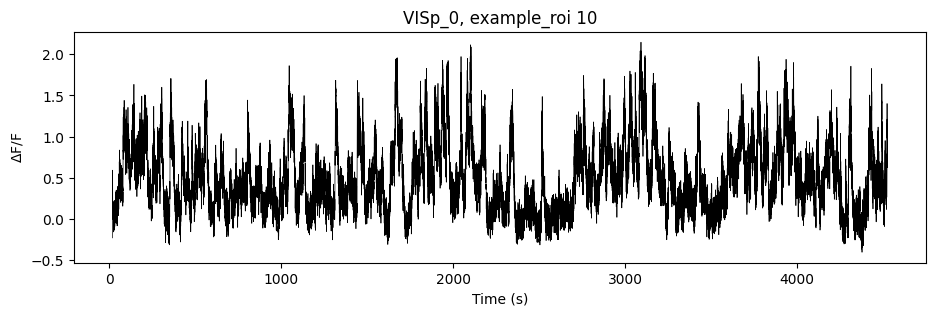

In [27]:
# The arbitrary choice: take a cell by its index and plot it.
example_roi = 10

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(ts, dff_after_qc[:, example_roi], 'k', lw=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'$\Delta$F/F')
ax.set_title(f'{plane}, example_roi {example_roi}')
plt.show()

In [28]:
# SELECTION RULE: highest signal-to-noise among cells whose baseline is stable.
snr = (np.percentile(dff_after_qc[:, usable_cells], 99, axis=0)
       / np.std(dff_after_qc[:, usable_cells], axis=0))

# A cell can have a high ratio because it is reliably active, or because its
# baseline wanders. Compare block means across the session to tell them apart.
blocks = np.array_split(np.arange(len(ts)), 8)
block_means = np.array([dff_after_qc[b][:, usable_cells].mean(axis=0) for b in blocks])
instability = block_means.std(axis=0) / dff_after_qc[:, usable_cells].std(axis=0)

stable = np.flatnonzero(instability < 0.35)
pick = stable[np.argmax(snr[stable])]
example_roi = int(usable_cells[pick])

print(f'example_roi {example_roi}: SNR {snr[pick]:.2f}, instability {instability[pick]:.2f}')
print(f'{len(stable)}/{len(usable_cells)} cells pass the stability threshold')

example_roi 52: SNR 4.16, instability 0.26
41/77 cells pass the stability threshold


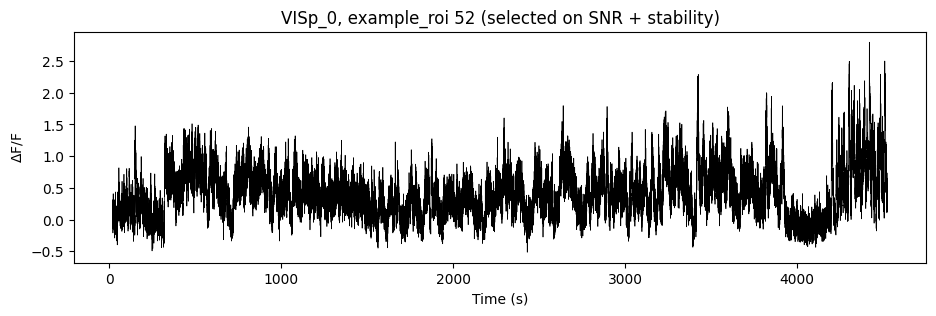

In [29]:
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(ts, dff_after_qc[:, example_roi], 'k', lw=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'$\Delta$F/F')
ax.set_title(f'{plane}, example_roi {example_roi} (selected on SNR + stability)')
plt.show()

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Find any other information needed to reproduce your classmate's plot. 
Is it showing task epochs? Stimulus presentations? 
Is there any behavioral information like reward times or running speed? 
Where do these pieces of data live in this dataset's NWB file structure?

</div>

In [30]:
# Pull out the other pieces your chosen figure needs -- stimulus/trial tables,
# and any behavioral traces the dataset has. 
# What are the columns of the tables? Which describe *what was
# presented*, which describe *what the animal did*, and which are bookkeeping?

In [31]:
# INTERVALS -- time periods within a session, could be a stimulus or a trial type or a stimulus block
# Note not all datasets have an intervals table within the intervals container - but this one does
intervals_table = nwb.intervals['intervals'].to_dataframe()
print('\ninterval_type values:', intervals_table.interval_type.value_counts().to_dict())
intervals_table.head()



interval_type values: {'movie_frame': 9000, 'stimulus_presentation': 4805, 'trial': 767, 'change_window': 527, 'response_window': 220, 'epoch': 4}


,start_time,stop_time,interval_type,label,trials_id,stimulus_presentations_id,natural_movie_one_presentations_id,HED
id,,,,,,,,
0,0.000000,318.837390,epoch,spontaneous,-1,-1,-1,"Time-block, Pause, Label/spontaneous"
1,318.837390,3925.469850,epoch,change_detection,-1,-1,-1,"Time-block, Experiment-procedure, Label/change..."
2,318.837390,320.088450,trial,,0,-1,-1,"Experimental-trial, Incorrect-action, Label/ab..."
3,318.873416,319.123626,stimulus_presentation,im000,-1,0,-1,"Sensory-event, Visual-presentation, (Image, La..."
4,319.624056,319.874256,stimulus_presentation,im000,-1,1,-1,"Sensory-event, Visual-presentation, (Image, La..."


In [32]:
# EPOCHS -- the coarse structure of the session. In this dataset they are NOT in
# the stimulus table: they live in a general-purpose `intervals` table that mixes
# several kinds of interval, so we keep only the epoch rows.
epochs = intervals_table[intervals_table.interval_type == 'epoch']
epochs = epochs.set_index('label')[['start_time', 'stop_time']].sort_values('start_time')
epochs['duration_s'] = (epochs.stop_time - epochs.start_time).round(1)
epochs.head()


,start_time,stop_time,duration_s
label,,,
spontaneous,0.000000,318.837390,318.8
change_detection,318.837390,3925.469850,3606.6
spontaneous,3925.469850,4225.759726,300.3
natural_movie_one,4225.759726,4526.013479,300.3


In [33]:
# STIMULUS / TRIAL TABLES -- what was presented

# This dataset has both stimulus_presentations and trials - what is in each? 
stimulus_table = nwb.intervals['stimulus_presentations'].to_dataframe()

print('stimulus_table columns:')
print(' ', list(stimulus_table.columns))
stimulus_table.head()

stimulus_table columns:
  ['start_time', 'stop_time', 'image_name', 'orientation', 'is_change', 'omitted', 'stimulus_presentations_id', 'trials_id', 'start_frame', 'stop_frame', 'lick_latency', 'epoch_name', 'HED']


,start_time,stop_time,image_name,orientation,is_change,omitted,stimulus_presentations_id,trials_id,start_frame,stop_frame,lick_latency,epoch_name,HED
id,,,,,,,,,,,,,
0,318.873416,319.123626,im000,NaN,False,False,0,0,17985,18000,0.681244,change_detection,"Sensory-event, Visual-presentation, (Image, La..."
1,319.624056,319.874256,im000,NaN,False,False,1,0,18030,18045,0.147454,change_detection,"Sensory-event, Visual-presentation, (Image, La..."
2,320.374686,320.624896,im000,NaN,False,False,2,1,18075,18090,0.297594,change_detection,"Sensory-event, Visual-presentation, (Image, La..."
3,321.125326,321.375536,im000,NaN,False,False,3,2,18120,18135,NaN,change_detection,"Sensory-event, Visual-presentation, (Image, La..."
4,321.875946,322.126166,im000,NaN,False,False,4,2,18165,18180,0.414364,change_detection,"Sensory-event, Visual-presentation, (Image, La..."


In [34]:
trials = nwb.intervals['trials'].to_dataframe()
print('\ntrials columns:')
print(' ', list(trials.columns))
trials.head()


trials columns:
  ['start_time', 'stop_time', 'go', 'catch', 'auto_rewarded', 'aborted', 'hit', 'miss', 'false_alarm', 'correct_reject', 'warm_up', 'change_time', 'change_frame', 'initial_image_name', 'change_image_name', 'initial_orientation', 'change_orientation', 'reward_time', 'reward_volume', 'response_time', 'response_latency', 'change_window_start_time', 'change_window_stop_time', 'response_window_start_time', 'response_window_stop_time', 'epoch_name', 'HED']


,start_time,stop_time,go,catch,auto_rewarded,aborted,hit,miss,false_alarm,correct_reject,warm_up,change_time,change_frame,initial_image_name,change_image_name,initial_orientation,change_orientation,reward_time,reward_volume,response_time,response_latency,change_window_start_time,change_window_stop_time,response_window_start_time,response_window_stop_time,epoch_name,HED
id,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,318.83739,320.08845,False,False,True,True,False,False,False,False,True,NaN,-1,im000,im000,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,change_detection,"Experimental-trial, Incorrect-action, Label/ab..."
1,320.33866,320.97253,False,False,True,True,False,False,False,False,True,NaN,-1,im000,im000,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,change_detection,"Experimental-trial, Incorrect-action, Label/ab..."
2,321.08930,322.60725,False,False,True,True,False,False,False,False,True,NaN,-1,im000,im000,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,change_detection,"Experimental-trial, Incorrect-action, Label/ab..."
3,323.34120,331.36465,False,False,True,False,False,False,False,False,True,327.130396,18480,im000,im075,NaN,NaN,327.2445,0.005,327.14441,0.014014,325.629126,327.130396,327.280396,327.880396,change_detection,"Experimental-trial, Reward, Label/auto_rewarde..."
4,331.59818,332.13197,False,False,True,True,False,False,False,False,True,NaN,-1,im075,im075,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,change_detection,"Experimental-trial, Incorrect-action, Label/ab..."


In [35]:
# EVENTS - discrete events that happened in the session
# Note not all datasets have an events table within the events container 
events_table = nwb.events['events'].to_dataframe()
print('events table columns:')
print(' ', list(events_table.columns))
events_table.head()

events table columns:
  ['timestamp', 'event_type', 'lick_classification', 'reward_type', 'lick_bouts', 'trials_id', 'stimulus_presentations_id', 'image_name', 'orientation', 'frame', 'reward_volume']


,timestamp,event_type,lick_classification,reward_type,lick_bouts,trials_id,stimulus_presentations_id,image_name,orientation,frame,reward_volume
id,,,,,,,,,,,
0,35.83161,lick,spontaneous,n/a,bout_start,-1,-1,,NaN,1019,NaN
1,37.38292,lick,spontaneous,n/a,bout_start,-1,-1,,NaN,1112,NaN
2,37.84998,lick,spontaneous,n/a,within_bout,-1,-1,,NaN,1140,NaN
3,75.58182,lick,spontaneous,n/a,bout_start,-1,-1,,NaN,3402,NaN
4,75.73194,lick,spontaneous,n/a,within_bout,-1,-1,,NaN,3411,NaN


In [36]:
# BEHAVIOR -- can be events or timeseries. 
# In some datasets, behavior information lives in the procesing container.
# Behavior events can also live in events tables. 
# Does your behavior signal need to be converted to an array or extracted as a dataframe?

# This dataset has running speed in the processing container
# Extract the running speed as an array and get the timestamps
speed_series = nwb.processing['running']['speed']
running_speed = np.asarray(speed_series.data[:])
running_timestamps = np.asarray(speed_series.timestamps[:])

print('running_speed :', running_speed.shape, '| running_timestamps:', running_timestamps.shape)
print(f'running sampled at {1 / np.median(np.diff(running_timestamps)):.1f} Hz '
      f'-- a different clock from the {1 / np.median(np.diff(ts)):.1f} Hz imaging')

running_speed : (270200,) | running_timestamps: (270200,)
running sampled at 60.0 Hz -- a different clock from the 9.5 Hz imaging


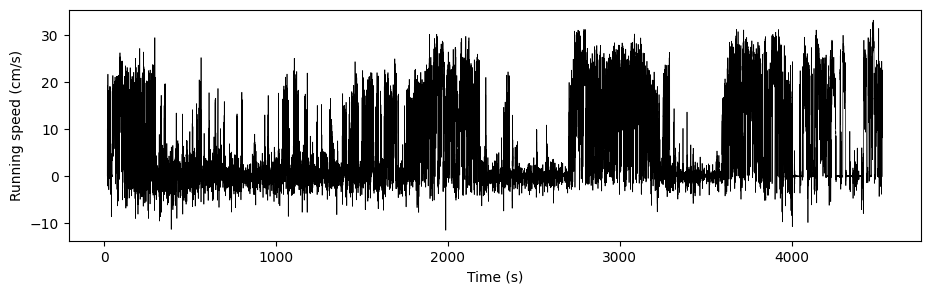

In [37]:
# Let's plot the running trace to see what it looks like
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(running_timestamps, running_speed, 'k', lw=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Running speed (cm/s)')
plt.show()

In [38]:
# We can also ask for all events using nwb.get_all_events()
behavior_events = nwb.get_all_events()
print('\nbehavioral event types:')
print(behavior_events.event_type.value_counts().to_string())


behavioral event types:
event_type
lick              2885
image_change       191
image_omission     161
reward              93


---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 2: Reproduce the figure, and interrogate what it shows</h1>

You have your classmate's figure. You do not have their code, and you may not have a caption either.

<b>Before you write anything, write down what you think the figure shows.</b> One or two sentences,
in your notebook, as a claim someone could disagree with: <i>"activity is higher during X than during
Y"</i>, <i>"the response is larger on this trial type"</i>, <i>"these two signals rise together."</i>

Two reasons this comes first. It commits you to an interpretation before the data can talk you into
one &mdash; and it converts a picture into something you can actually test. A figure cannot be right
or wrong. A claim can.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Write your claim about the figure you picked, in the cell below, before you
write any code.

Be specific enough to be wrong. "There is neural activity" is not a claim; "population activity is
higher in the second half of the session" is.

</div>

_Your claim:_

The example figure is a session overview: running speed and population mean dF/F across
the whole session, with the task epochs shaded behind them. The claim it suggests is

> *"Population activity is higher during the change detection task block than during the
> gray screen periods and is highly correlated with running speed."*

Two things make this testable rather than decorative: it names the two things being compared
and it asserts a direction. Note that it is really two claims, and they may not both survive.


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Now replicate it</h3>

Get the pieces the figure needs and plot them. 

As you do this, consider the following: 
* What are the decisions that go into making this figure? 
* What pieces of information are present? Are they timeseries, events, epochs? 
* Can you tell how it was filtered, if at all? 
* Are there pieces of data you would have included but they did not?
* How do the decisions made during data visualization influence your understanding of the data?


</div>

In [39]:
# Let's save our activity traces and timestamps with generalizeable names to use in the rest of the notebook

# =====================================================================
# FILL IN FOR YOUR DATASET
# =====================================================================
activity = dff                    # (n_timepoints, n_cells)
timestamps = ts                   # (n_timepoints,) seconds
events = stimulus_table           # one row per stimulus presentation


# A second activity representation, if your dataset has one (deconvolved
# events, spike estimates). Set to None if it does not -- the notebook adapts.
# NOTE: this must carry the same QC mask as `activity`.
activity_events = events_data
second_signal_label = 'event magnitude'   # what activity_events holds; None if unused
# =====================================================================

print('activity:', activity.shape, '| events:', events.shape)
print('second representation:',
      'none' if activity_events is None else activity_events.shape)

activity: (42721, 80) | events: (4805, 13)
second representation: (42721, 80)


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Plot the same data features that your classmate found in this dataset. 

Do you need to transform the neural activity data in some way?  
Do you need to convert to spike rate or average across the population?  
Which neurons are included? What time period is the plot showing?

Once youve built the plot - What is going on in this session? 
</div>

In [40]:
# Compute whatever your chosen figure shows, or plot the data directly.
# For a population average, the mean across cells at each timepoint.
# For running speed, a single timeseries.
# Are there discrete events? Are all available events included?

# The figure needs a population average: mean across cells at each timepoint.
population_rate = activity.mean(axis=1)

print('all cells  :', activity.shape, '(timepoints, cells)')
print('population activity:', population_rate.shape, '(timepoints,)')

# Epochs are shown in the background
epochs.head()


all cells  : (42721, 80) (timepoints, cells)
population activity: (42721,) (timepoints,)


,start_time,stop_time,duration_s
label,,,
spontaneous,0.000000,318.837390,318.8
change_detection,318.837390,3925.469850,3606.6
spontaneous,3925.469850,4225.759726,300.3
natural_movie_one,4225.759726,4526.013479,300.3


In [41]:
# Here is a helper function from the tutorial in case you need it 

def shade_epoch_blocks(epochs, ax):
    """Shade each epoch on `ax`, one color per epoch label.

    Epochs are the coarse structure of the session -- which stimulus block or
    task phase was running. Shading them behind a trace shows at a glance
    whether a change in activity lines up with a change in what was happening.
    """

    colors = dict(zip(epochs.index, plt.cm.Pastel1.colors))

    for label, row in epochs.iterrows():
        # zorder=0 keeps the shading BEHIND the data; alpha so the trace on top
        # stays readable. label= puts each epoch in the legend once.
        ax.axvspan(row.start_time, row.stop_time, color=colors[label],
                   alpha=0.5, zorder=0, label=label)

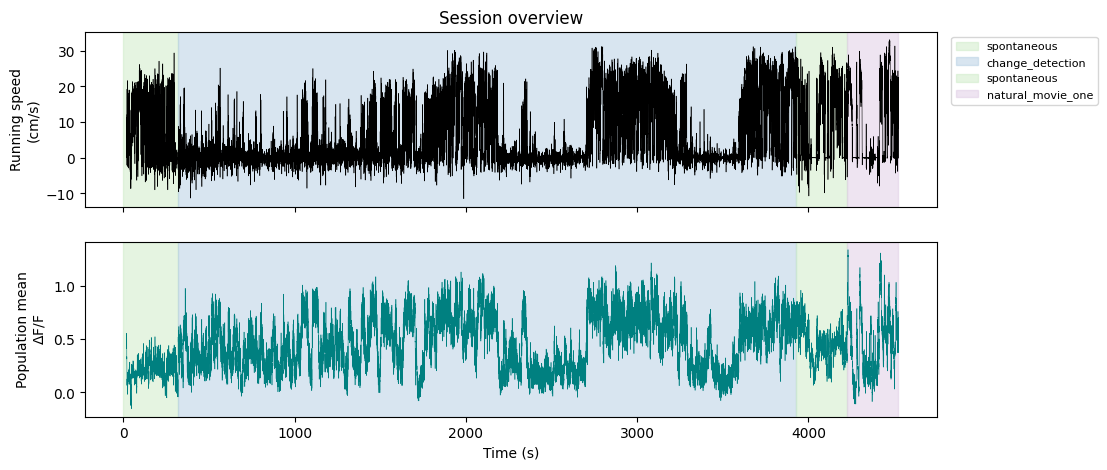

In [42]:
# Two panels sharing an x axis: what the animal did, and what the population did.
fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)

axes[0].plot(running_timestamps, running_speed, 'k', lw=0.4)
axes[0].set_ylabel('Running speed\n(cm/s)')
axes[0].set_title('Session overview')

axes[1].plot(timestamps, population_rate, color='teal', lw=0.4)
axes[1].set_ylabel('Population mean\n' + r'$\Delta$F/F')
axes[1].set_xlabel('Time (s)')

for ax in axes:
    shade_epoch_blocks(epochs, ax)

axes[0].legend(bbox_to_anchor=(1.01, 1.0), loc='upper left', fontsize=8)
plt.show()

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**[Optional] Exercise:** Now test the claim you wrote above.

Turn your sentence into a number you can check. If it compares epochs, compute the mean in each one,
alongside how long each epoch lasted, when in the session it happened, and what the animal was doing.
If it compares something else, compute the equivalent.

Before you look: **what would make this comparison unfair?** Write your answer down first, then see
whether the table bears it out.

Is claim as supported, contradicted, or untestable with this data? 

</div>

In [43]:
# For each epoch compute the mean activity, and alongside it the things that
# could confound the comparison: how long the epoch lasted, how many samples
# that is, when in the session it happened, and what the animal was doing.
# Build a DataFrame with one row per epoch.

rows = []
for label, row in epochs.iterrows():
    in_epoch = (timestamps >= row.start_time) & (timestamps < row.stop_time)
    in_epoch_run = (running_timestamps >= row.start_time) & (running_timestamps < row.stop_time)
    rows.append({'epoch': label,
                 'duration_s': round(row.stop_time - row.start_time, 1),
                 'n_samples': in_epoch.sum(),
                 'mid_session_min': round((row.start_time + row.stop_time) / 120, 1),
                 'mean_running': round(running_speed[in_epoch_run].mean(), 2),
                 'mean_activity': round(population_rate[in_epoch].mean(), 4)})

epoch_summary = pd.DataFrame(rows)
epoch_summary

,epoch,duration_s,n_samples,mid_session_min,mean_running,mean_activity
0,spontaneous,318.8,2844,2.7,8.11,0.2080
1,change_detection,3606.6,34186,35.4,6.02,0.4707
2,spontaneous,300.3,2846,67.9,10.06,0.4617
3,natural_movie_one,300.3,2845,72.9,8.91,0.4515


---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 3: Align activity to event onsets</h1>

Let's go beyond the figure your classmate made. 

A session overview shows everything at once, which means it shows very little. To see a response
you need to **align** activity to the times when something happened, and look across repeats, not just the average.

This morning's tutorial averaged across presentations. Here we look at what the average hides.

Note that "something happened" need not be a visual stimulus. It might be a sound, an optogenetic pulse, a
reward, a lick, or the start of a trial. Anything with a repeatable onset time works the same way
&mdash; and the rest of this notebook says "event" rather than "stimulus" for that reason.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Identify events of interest. Check the stimulus, trials, intervals, and events tables to see what is available. 

What is happening during this session? What is the subject experiencing? Are there distinct stimuli, trial types, behavior events?

Explore the available conditions and select a specific type of event to examine further. 

</div>

In [44]:
# STIMULUS TABLES -- what was presented
stimulus_table = nwb.intervals['stimulus_presentations'].to_dataframe()
print('stimulus_table columns:')
print(' ', list(stimulus_table.columns))
stimulus_table.head()

stimulus_table columns:
  ['start_time', 'stop_time', 'image_name', 'orientation', 'is_change', 'omitted', 'stimulus_presentations_id', 'trials_id', 'start_frame', 'stop_frame', 'lick_latency', 'epoch_name', 'HED']


,start_time,stop_time,image_name,orientation,is_change,omitted,stimulus_presentations_id,trials_id,start_frame,stop_frame,lick_latency,epoch_name,HED
id,,,,,,,,,,,,,
0,318.873416,319.123626,im000,NaN,False,False,0,0,17985,18000,0.681244,change_detection,"Sensory-event, Visual-presentation, (Image, La..."
1,319.624056,319.874256,im000,NaN,False,False,1,0,18030,18045,0.147454,change_detection,"Sensory-event, Visual-presentation, (Image, La..."
2,320.374686,320.624896,im000,NaN,False,False,2,1,18075,18090,0.297594,change_detection,"Sensory-event, Visual-presentation, (Image, La..."
3,321.125326,321.375536,im000,NaN,False,False,3,2,18120,18135,NaN,change_detection,"Sensory-event, Visual-presentation, (Image, La..."
4,321.875946,322.126166,im000,NaN,False,False,4,2,18165,18180,0.414364,change_detection,"Sensory-event, Visual-presentation, (Image, La..."


In [45]:
# TRIALS TABLES - when mice perform a task the data can be broken into distinct trials
trials = nwb.intervals['trials'].to_dataframe()
print('\ntrials columns:')
print(' ', list(trials.columns))
trials.head()


trials columns:
  ['start_time', 'stop_time', 'go', 'catch', 'auto_rewarded', 'aborted', 'hit', 'miss', 'false_alarm', 'correct_reject', 'warm_up', 'change_time', 'change_frame', 'initial_image_name', 'change_image_name', 'initial_orientation', 'change_orientation', 'reward_time', 'reward_volume', 'response_time', 'response_latency', 'change_window_start_time', 'change_window_stop_time', 'response_window_start_time', 'response_window_stop_time', 'epoch_name', 'HED']


,start_time,stop_time,go,catch,auto_rewarded,aborted,hit,miss,false_alarm,correct_reject,warm_up,change_time,change_frame,initial_image_name,change_image_name,initial_orientation,change_orientation,reward_time,reward_volume,response_time,response_latency,change_window_start_time,change_window_stop_time,response_window_start_time,response_window_stop_time,epoch_name,HED
id,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,318.83739,320.08845,False,False,True,True,False,False,False,False,True,NaN,-1,im000,im000,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,change_detection,"Experimental-trial, Incorrect-action, Label/ab..."
1,320.33866,320.97253,False,False,True,True,False,False,False,False,True,NaN,-1,im000,im000,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,change_detection,"Experimental-trial, Incorrect-action, Label/ab..."
2,321.08930,322.60725,False,False,True,True,False,False,False,False,True,NaN,-1,im000,im000,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,change_detection,"Experimental-trial, Incorrect-action, Label/ab..."
3,323.34120,331.36465,False,False,True,False,False,False,False,False,True,327.130396,18480,im000,im075,NaN,NaN,327.2445,0.005,327.14441,0.014014,325.629126,327.130396,327.280396,327.880396,change_detection,"Experimental-trial, Reward, Label/auto_rewarde..."
4,331.59818,332.13197,False,False,True,True,False,False,False,False,True,NaN,-1,im075,im075,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,change_detection,"Experimental-trial, Incorrect-action, Label/ab..."


In [46]:
# EVENTS - discrete events that happened in the session
# Note not all datasets have an events table within the events container 
events_table = nwb.events['events'].to_dataframe()
print('events table columns:')
print(' ', list(events_table.columns))
events_table.head()

events table columns:
  ['timestamp', 'event_type', 'lick_classification', 'reward_type', 'lick_bouts', 'trials_id', 'stimulus_presentations_id', 'image_name', 'orientation', 'frame', 'reward_volume']


,timestamp,event_type,lick_classification,reward_type,lick_bouts,trials_id,stimulus_presentations_id,image_name,orientation,frame,reward_volume
id,,,,,,,,,,,
0,35.83161,lick,spontaneous,n/a,bout_start,-1,-1,,NaN,1019,NaN
1,37.38292,lick,spontaneous,n/a,bout_start,-1,-1,,NaN,1112,NaN
2,37.84998,lick,spontaneous,n/a,within_bout,-1,-1,,NaN,1140,NaN
3,75.58182,lick,spontaneous,n/a,bout_start,-1,-1,,NaN,3402,NaN
4,75.73194,lick,spontaneous,n/a,within_bout,-1,-1,,NaN,3411,NaN


In [47]:
# INTERVALS -- time periods within a session, could be a stimulus or a trial type or a stimulus block
# Note not all datasets have an intervals table within the intervals container 
intervals_table = nwb.intervals['intervals'].to_dataframe()
print('columns:', intervals_table.columns)
intervals_table.head()


columns: Index(['start_time', 'stop_time', 'interval_type', 'label', 'trials_id', 'stimulus_presentations_id', 'natural_movie_one_presentations_id', 'HED'], dtype='object')


,start_time,stop_time,interval_type,label,trials_id,stimulus_presentations_id,natural_movie_one_presentations_id,HED
id,,,,,,,,
0,0.000000,318.837390,epoch,spontaneous,-1,-1,-1,"Time-block, Pause, Label/spontaneous"
1,318.837390,3925.469850,epoch,change_detection,-1,-1,-1,"Time-block, Experiment-procedure, Label/change..."
2,318.837390,320.088450,trial,,0,-1,-1,"Experimental-trial, Incorrect-action, Label/ab..."
3,318.873416,319.123626,stimulus_presentation,im000,-1,0,-1,"Sensory-event, Visual-presentation, (Image, La..."
4,319.624056,319.874256,stimulus_presentation,im000,-1,1,-1,"Sensory-event, Visual-presentation, (Image, La..."


In [48]:
# Let's use the image presentations as our event of interest.
# Note this dataset keeps them in intervals['stimulus_presentations'], NOT in the
# general-purpose intervals['intervals'] table -- that one mixes trials, epochs
# and movie frames together and has no image_name or is_change column.
condition_column = 'image_name'
onset_column = 'start_time'
# Save the table to a variable called 'events' so we can keep track of it
events = stimulus_table.copy()

print('events:', events.shape)
print('columns:', list(events.columns))

events: (4805, 13)
columns: ['start_time', 'stop_time', 'image_name', 'orientation', 'is_change', 'omitted', 'stimulus_presentations_id', 'trials_id', 'start_frame', 'stop_frame', 'lick_latency', 'epoch_name', 'HED']


In [49]:
# How many times was each chosen condition presented?
# Are there different variations on a given event type?
# How does your selection of event types and conditions influence the amount of data you have?

# What are the different conditions of this type? 
print('presentations of each image:')
print(events[condition_column].value_counts().to_string())

# The same image appears as a change, as a repeat, and as an omission -- three
# different kinds of event sharing one image_name. Every time you subdivide, you
# lose an order of magnitude of trials.
print('\nall presentations:', len(events))
print('changes only     :', (events.is_change == 1).sum())
print('repeats only     :', ((events.is_change != 1) & (events.omitted != 1)).sum())
print('omissions        :', (events.omitted == 1).sum())

presentations of each image:
image_name
im106      771
im031      699
im075      597
im045      582
im000      548
im054      537
im073      480
im035      430
omitted    161

all presentations: 4805
changes only     : 191
repeats only     : 4453
omissions        : 161


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Are all of these events the same kind of event?</h3>

An event table usually contains rows that are **not equivalent trials**. Depending on the dataset
that might be first versus repeated presentations, rewarded versus unrewarded trials, different
stimulus families, trials the animal responded to versus ignored, blocks recorded before and after
a manipulation, or blank and omitted entries that are not events at all.

This matters before you align anything, for two reasons:

- **Response magnitude can differ several-fold between trial types.** Averaging them together dilutes
  the response toward whichever type is most numerous &mdash; which is often the weakest one.
- **Trial types differ in what else is happening.** Reward, licking, and arousal ride along with some
  trial types and not others, so a difference you attribute to the stimulus may not be about the
  stimulus.

Find the columns in your table that distinguish trial types, and count them.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Pick two conditions from your table and pull out the onset times of each. How many
repetitions are there of each one?

**Name the variables for what they hold.** By the end of this notebook you will have a dozen arrays
of aligned windows, masks, and subsets of subsets, and nothing in the code will remind you which is
which. `change_onset_times` and `repeat_onset_times` tell you their contents every time you read
them; `event_times_a` and `event_times_b` mean you have to scroll back to find out. The same goes
for indices: a cell index derived from one activity matrix no longer points at the same neuron once
you subset the cells, so re-derive it rather than carrying it forward.

</div>

In [50]:
# Two conditions to compare, named for what they are: image changes vs. repeated
# presentations of the same image.
change_onset_times = events.loc[events.is_change == 1, onset_column].values
repeat_onset_times = events.loc[(events.is_change != 1) & (events.omitted != 1),
                                onset_column].values

print('change_onset_times:', len(change_onset_times), 'presentations')
print('repeat_onset_times:', len(repeat_onset_times), 'presentations')

change_onset_times: 191 presentations
repeat_onset_times: 4453 presentations


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Align the population average to
each event separately, then plot both on the same axes.

Write down your prediction first: do you expect a difference, and how large?

</div>

_Your prediction:_

Prediction: change trials will evoke a clearly larger population response than repeats,
by a factor of two or more. The repeated images are presented every 0.75 s in a continuous
stream, so the population should be adapted to them; a change breaks that stream and is also
the event the animal is trained to report, so reward and licking ride along with it.

Committing to "two or more" rather than "a difference" is what makes the prediction checkable
— if the observed ratio came out at 1.1, the prediction would be wrong even though the
direction was right.


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

To compare them we need to cut a window of data around each onset. Same
`align_to_event_times` helper as this morning's tutorial.

</div>

In [51]:
# Here is the helper function from today's tutorial, with comments added so you can follow the logic

def align_to_event_times(data, timestamps, event_times, pre=0.5, post=1.5):
    """Cut a window of data around each event time.

    data        : array with time along the first axis
    timestamps  : time of each row of data, in seconds
    event_times : times to align to, in seconds
    pre, post   : seconds before and after each event

    Returns (aligned_windows, window_time_axis) where the time axis is in
    seconds relative to the event, and there is one window per usable_cells event.
    """
    # Sampling interval. Median, not mean: one gap in the recording would
    # inflate a mean and silently shrink every window.
    dt = np.median(np.diff(timestamps))

    # Convert the requested seconds into a number of samples. int() truncates,
    # so a window that is not a whole number of samples comes out slightly
    # short -- check this if you need exact window edges.
    n_pre, n_post = int(pre / dt), int(post / dt)

    aligned_windows = []
    for event_time in event_times:
        # Index of the first sample AT OR AFTER the event. side='left' returns
        # the insertion point, so timestamps[i] >= event_time always.
        #
        # Do NOT round to the nearest sample: that pulls roughly half the
        # trials one sample EARLIER than the event, which smears the onset and
        # can make a real response look like it starts before the stimulus.
        # Landing just after is honest -- the bias is one-directional and at
        # most one sample.
        i = np.searchsorted(timestamps, event_time, side='left')

        # Skip events too close to either end of the recording to fill a whole
        # window. This drops trials SILENTLY, so compare
        # aligned_windows.shape[0] against len(event_times) afterwards.
        if i - n_pre >= 0 and i + n_post <= len(timestamps):
            # Slice is n_pre + n_post samples long. Index n_pre within the
            # window is the first sample at/after the event, i.e. t = 0.
            aligned_windows.append(data[i - n_pre:i + n_post])

    # Time axis in seconds relative to the event. Starts at -n_pre*dt, which
    # can be slightly later than -pre because of the truncation above.
    window_time_axis = np.arange(-n_pre, n_post) * dt
    return np.array(aligned_windows), window_time_axis

In [52]:
# Feed your population average timeseries and your event times into the helper function, once for each condition
# Consider what window around each event you want to look at and adjust the input parameters to the function accordingly

# The stimulus repeats every 0.75 s, so a longer post window runs into the next presentation.
pre, post = 0.5, 1.0

aligned_change, window_time_axis = align_to_event_times(population_rate, timestamps,
                                                       change_onset_times, pre=pre, post=post)
aligned_repeat, _ = align_to_event_times(population_rate, timestamps,
                                         repeat_onset_times, pre=pre, post=post)

print('aligned_change:', aligned_change.shape, '(n_events, n_frames)')
print('aligned_repeat:', aligned_repeat.shape, '(n_events, n_frames)')

aligned_change: (191, 13) (n_events, n_frames)
aligned_repeat: (4453, 13) (n_events, n_frames)


In [53]:
# What does the output look like?
# Compare the number of windows you got back against the number of onsets you asked for. Are they the same?

print('changes: asked for', len(change_onset_times), '| got back', aligned_change.shape[0])
print('repeats: asked for', len(repeat_onset_times), '| got back', aligned_repeat.shape[0])
print(f'\nwindow spans {window_time_axis[0]:+.2f} to {window_time_axis[-1]:+.2f} s '
      f'in {len(window_time_axis)} samples')

changes: asked for 191 | got back 191
repeats: asked for 4453 | got back 4453

window spans -0.42 to +0.84 s in 13 samples


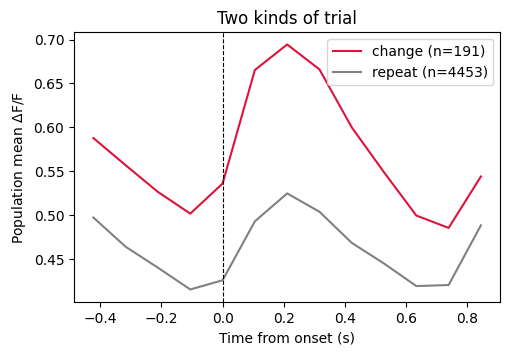

In [54]:
# Take the mean across the aligned windows for each condition and plot them on the same axis. Label them accordingly.
# Make sure you understand the units of the x and y axes and label them as well.

# x: seconds relative to onset. y: dF/F averaged over cells, then over trials --
# a unitless fractional change in fluorescence, not a firing rate.
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(window_time_axis, aligned_change.mean(axis=0), color='crimson',
        label=f'change (n={len(aligned_change)})')
ax.plot(window_time_axis, aligned_repeat.mean(axis=0), color='gray',
        label=f'repeat (n={len(aligned_repeat)})')
ax.axvline(0, color='k', ls='--', lw=0.8)
ax.set_xlabel('Time from onset (s)')
ax.set_ylabel('Population mean ' + r'$\Delta$F/F')
ax.set_title('Two kinds of trial')
ax.legend()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

What are some decisions you can make in how you process and plot the data that can affect your interpretation? 

Should you subtract the pre-event baseline? Or are you interested in the baseline activity level? 

What happens if you bin the data with a different window? 

</div>

In [55]:
# A note on baseline subtraction: exclude the sample immediately before event onset from your baseline window.
# With binned or sampled data that sample can straddle the event,  including
# it puts part of the response into the baseline and shrinks what you
# measure. e.g. `window_time_axis < -bin_width` rather than `< 0`.

bin_width = np.median(np.diff(window_time_axis))
is_baseline = window_time_axis < -bin_width

print(f'sample interval {1000 * bin_width:.1f} ms')
print('baseline samples with `< -bin_width`:', is_baseline.sum())
print('baseline samples with `< 0`         :', (window_time_axis < 0).sum())

sample interval 105.5 ms
baseline samples with `< -bin_width`: 3
baseline samples with `< 0`         : 4


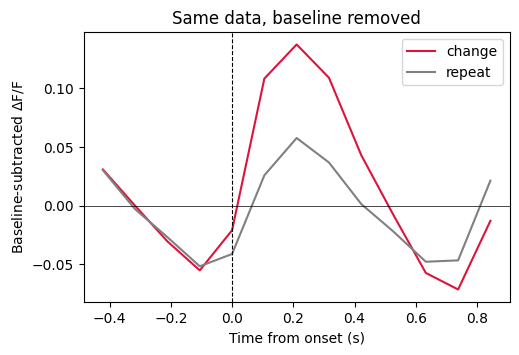

In [56]:
# Subtracting the baseline asks "how much did the stimulus change activity".
# Keeping it asks "how active was the population around this event".
mean_change = aligned_change.mean(axis=0)
mean_repeat = aligned_repeat.mean(axis=0)

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(window_time_axis, mean_change - mean_change[is_baseline].mean(),
        color='crimson', label='change')
ax.plot(window_time_axis, mean_repeat - mean_repeat[is_baseline].mean(),
        color='gray', label='repeat')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', ls='--', lw=0.8)
ax.set_xlabel('Time from onset (s)')
ax.set_ylabel('Baseline-subtracted ' + r'$\Delta$F/F')
ax.set_title('Same data, baseline removed')
ax.legend()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Are you looking at the right signal?</b>

Most datasets ship more than one representation of the same activity. &Delta;F/F carries the
indicator's rise and decay, so a brief response is smeared forward by hundreds of milliseconds.
Deconvolved events estimate when the cell actually fired, so they are temporally tighter but mostly
exact zeros &mdash; which makes single-trial estimates much noisier even though the trial average
looks cleaner. Spike times are discrete, and you choose the bin width yourself.

None is more correct; it depends on your question. A question about response <i>latency</i> is badly
served by &Delta;F/F, and one needing a reliable per-trial number is badly served by a sparse
signal. Pick one, say why, and if you have time run the analysis twice and compare.

</div>

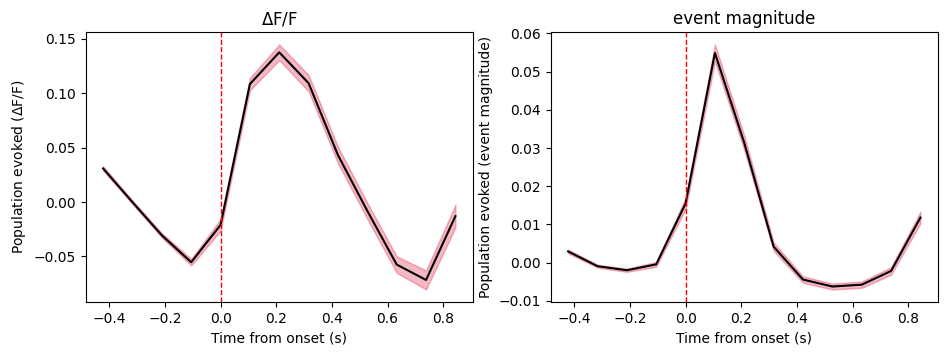

In [57]:
# If your dataset has more than one type of signal, recreate the plot above for each. Plot them side by side.
# What are the differences? How would it affect your interpretation?

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

for ax, (label, signal) in zip(axes, [(r'$\Delta$F/F', activity),
                                      ('event magnitude', activity_events)]):
    windows, t_signal = align_to_event_times(signal.mean(axis=1), timestamps,
                                             change_onset_times, pre=0.5, post=1.0)
    bin_width = np.median(np.diff(t_signal))
    baseline = windows[:, t_signal < -bin_width].mean(axis=1, keepdims=True)
    evoked = windows - baseline

    mean = evoked.mean(axis=0)
    standard_error = evoked.std(axis=0) / np.sqrt(len(evoked))

    ax.plot(t_signal, mean, 'k')
    ax.fill_between(t_signal, mean - standard_error, mean + standard_error,
                    color='crimson', alpha=0.3)
    ax.axvline(0, color='red', ls='--', lw=1)
    ax.set_xlabel('Time from onset (s)')
    ax.set_ylabel(f'Population evoked ({label})')
    ax.set_title(label)

plt.show()

In [58]:
# The events trace is sparse; dF/F is not. That is the whole difference.
print(f'fraction exactly zero -- dff {np.mean(activity == 0):.3f}, '
      f'events {np.mean(activity_events == 0):.3f}')

fraction exactly zero -- dff 0.000, events 0.856


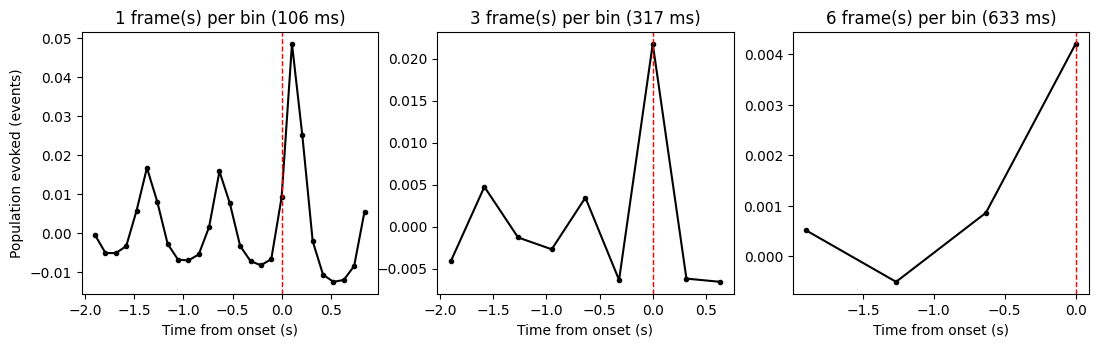

In [59]:
# Even if your dataset only has one signal (spike times), your choice of binning can affect the result
# Try recreating the spike times array with different bin widths and plot the average event aligned response with both versions side by side

# This dataset has no spike times -- dF/F and events are already binned at the
# imaging frame rate. Averaging adjacent frames asks the same question a coarser
# bin would: how much does temporal resolution change the answer?
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))

for ax, n_bin in zip(axes, [1, 3, 6]):
    n_keep = (len(timestamps) // n_bin) * n_bin
    coarse = activity_events[:n_keep].reshape(-1, n_bin, activity_events.shape[1]).mean(axis=1)
    coarse_timestamps = timestamps[:n_keep].reshape(-1, n_bin).mean(axis=1)

    windows, t_coarse = align_to_event_times(coarse.mean(axis=1), coarse_timestamps,
                                             change_onset_times, pre=2.0, post=1.0)
    bin_width = np.median(np.diff(t_coarse))
    baseline = windows[:, t_coarse < -bin_width].mean(axis=1, keepdims=True)

    ax.plot(t_coarse, (windows - baseline).mean(axis=0), 'k', marker='o', ms=3)
    ax.axvline(0, color='red', ls='--', lw=1)
    ax.set_xlabel('Time from onset (s)')
    ax.set_title(f'{n_bin} frame(s) per bin ({1000 * bin_width:.0f} ms)')

axes[0].set_ylabel('Population evoked (events)')
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>What does the average hide?</h3>

Everything so far has been an average &mdash; over cells, then over trials. Averaging is what makes a
small response visible, but it also throws away the two things that make population data
interesting.

<b>Variability across cells.</b> Neurons are highly heterogeneous, and understanding that diversity
is a central goal of neuroscience. A population average of a hundred cells can look like a modest
response whether every cell responded modestly or five cells responded strongly and ninety-five did
nothing at all.

<b>Variability across trials.</b> Present the identical stimulus fifty times and no neuron gives the
same answer twice. Some of that is measurement noise, but much of it is real: arousal, running,
recent stimulus history, and whatever else the brain was doing on that particular trial.

Both are invisible in a mean trace, so the next two plots put them back &mdash; every trial of one
cell, then every cell of one condition. Part 4 then turns each kind of variability into a number.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Choose an example cell to look at, and say how you chose it.

Papers often show example cells without disclosing how they were selected. Taking the first cell in
the table is effectively a random sample; selecting the most responsive cell is a different choice
that changes your impression of the data. Either is defensible &mdash; state which you did.

</div>

In [60]:
# Choose an example cell - it can be random, based on activity level, or based on some metric
# Write down the rationale for your selection criterion

# Work with the change trials, and the most frequent image within them, so the
# raster below has enough rows to read.
is_change_trial = events.is_change == 1
chosen_condition = events.loc[is_change_trial, condition_column].value_counts().index[0]
onset_times = events.loc[is_change_trial & (events[condition_column] == chosen_condition),
                         onset_column].values

print('condition:', chosen_condition, '| presentations:', len(onset_times))

condition: im075 | presentations: 25


In [61]:
# SELECTION RULE: the most stimulus-modulated cell -- its mean evoked response
# divided by the standard deviation of that response across trials. This is
# deliberately biased: it guarantees the example looks responsive. The heatmap
# further down gives the unbiased population picture.
windows, t_window = align_to_event_times(activity, timestamps, change_onset_times,
                                         pre=0.5, post=0.5)
bin_width = np.median(np.diff(t_window))

evoked = (windows[:, t_window >= 0].mean(axis=1)
          - windows[:, t_window < -bin_width].mean(axis=1))
modulation = evoked.mean(axis=0) / evoked.std(axis=0)
example_roi = int(np.argmax(modulation))

print('windows:', windows.shape, '(n_trials, n_timepoints, n_cells)')
print(f'most modulated cell: {example_roi} (score {modulation[example_roi]:.3f})')
print(f'median across cells: {np.median(modulation):.3f} -- the example is not typical')

windows: (191, 8, 80) (n_trials, n_timepoints, n_cells)
most modulated cell: 12 (score 1.395)
median across cells: 0.540 -- the example is not typical


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Raster vs PSTH</h3>

The event-aligned average is also called a PSTH (peri-stimulus time histogram); a plot showing every
individual trial is called a raster. Plot them together so you can see what the average discards.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** For one of your two conditions, plot the raster and the PSTH side by side. 

Using the same cell you've been working with, show the response for every trial as a heatmap (rows are trials, columns are timepoints). This is a raster.

Then plot the PSTH as the average across trials with the across trial variance as errorbars. 
Compute the standard error of the mean (standard deviation across trials divided by the square root of number of trials) 
and plot errorbars using matplotlib's fill_between()

</div>

In [62]:
# Plot the raster and the PSTH side by side: every trial as a heatmap, and
# the trial average with a measure of variability acros trials.

aligned_windows, t = align_to_event_times(activity[:, example_roi], timestamps,
                                          onset_times, pre=pre, post=post)

mean = aligned_windows.mean(axis=0)
standard_error = aligned_windows.std(axis=0) / np.sqrt(len(aligned_windows))

print('aligned_windows:', aligned_windows.shape, '(n_trials, n_timepoints)')

aligned_windows: (25, 13) (n_trials, n_timepoints)


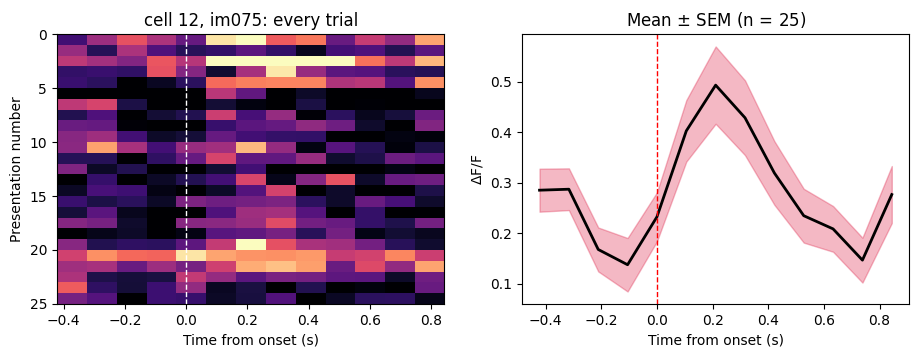

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

# Colour limit at the 98th percentile so a few bright frames do not wash out the rest.
vmax = np.percentile(aligned_windows, 98)

axes[0].imshow(aligned_windows, aspect='auto', cmap='magma', vmin=0, vmax=vmax,
               extent=[t[0], t[-1], len(aligned_windows), 0])
axes[0].axvline(0, color='white', ls='--', lw=1)
axes[0].set_ylabel('Presentation number')
axes[0].set_title(f'cell {example_roi}, {chosen_condition}: every trial')

axes[1].plot(t, mean, 'k', lw=2)
axes[1].fill_between(t, mean - standard_error, mean + standard_error,
                     color='crimson', alpha=0.3)
axes[1].axvline(0, color='red', ls='--', lw=1)
axes[1].set_ylabel(r'$\Delta$F/F')
axes[1].set_title(f'Mean $\\pm$ SEM (n = {len(aligned_windows)})')

for ax in axes:
    ax.set_xlabel('Time from onset (s)')
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>PSTH across cells</h3>

We have now seen average differences across conditions on average, variability across trials for one cell - how about variability across cells for one condition?

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Now compute the average response for every cell and plot the result as a heatmap, sorted by
response magnitude. How many cells respond?

</div>

In [64]:
# Build an array of (n_cells, n_timepoints) where the value for each cell is the condition mean
# Plot the response array as a heatmap, sorted by response magnitude.

responses = []
for roi in range(activity.shape[1]):
    windows_roi, t = align_to_event_times(activity[:, roi], timestamps,
                                          onset_times, pre=pre, post=post)
    responses.append(windows_roi.mean(axis=0))

responses = np.array(responses)
print('responses shape (n_cells, n_timepoints):', responses.shape)

responses shape (n_cells, n_timepoints): (80, 13)


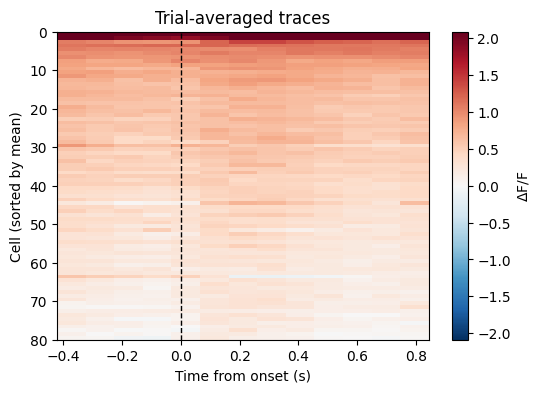

In [65]:
order = np.argsort(responses.mean(axis=1))[::-1]

# Diverging colormap, so make the limits symmetric around zero.
vmax = np.percentile(np.abs(responses), 98)

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(responses[order], aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax,
               extent=[t[0], t[-1], len(responses), 0])
ax.axvline(0, color='k', ls='--', lw=1)
ax.set_xlabel('Time from onset (s)')
ax.set_ylabel('Cell (sorted by mean)')
ax.set_title('Trial-averaged traces')
plt.colorbar(im, ax=ax, label=r'$\Delta$F/F')
plt.show()

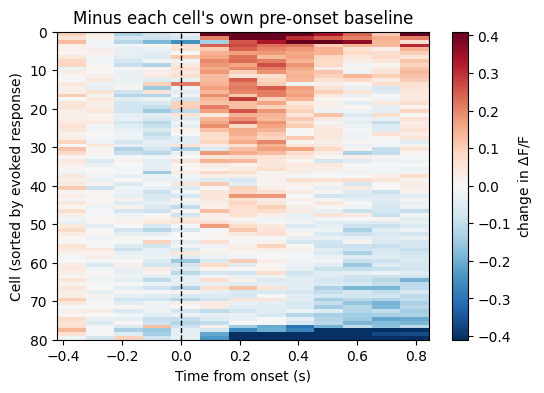

In [66]:
# Plot it again with each cell's own pre-onset baseline subtracted, and compare the two versions.
# How does baseline subtraction influence the interpretation?
# Was this the appropriate thing to do given the stimulus or event conditions you are using?

bin_width = np.median(np.diff(t))
baseline = responses[:, t < -bin_width].mean(axis=1, keepdims=True)
change = responses - baseline

order = np.argsort(change[:, t >= 0].mean(axis=1))[::-1]
vmax = np.percentile(np.abs(change), 98)

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(change[order], aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax,
               extent=[t[0], t[-1], len(change), 0])
ax.axvline(0, color='k', ls='--', lw=1)
ax.set_xlabel('Time from onset (s)')
ax.set_ylabel('Cell (sorted by evoked response)')
ax.set_title("Minus each cell's own pre-onset baseline")
plt.colorbar(im, ax=ax, label=r'change in $\Delta$F/F')
plt.show()

In [67]:
# Sorting the RAW panel by row mean sorts by baseline, not by response.
# After subtraction a minority of cells respond and a few are suppressed.
evoked = change[:, t >= 0].mean(axis=1)
print('cells that increase:', (evoked > 0).sum(), '/', len(evoked))
print('cells that decrease:', (evoked < 0).sum())

cells that increase: 47 / 80
cells that decrease: 33


---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 4: Signal and noise correlations</h1>

<h3>What are signal and noise correlations, and what can they tell us?</h3>

A single neuron's average response to a stimulus is the most reported measurement in systems
neuroscience, and it is also one of the least informative things you can compute from a population
recording. Neurons do not act alone. Two cells recorded at the same time can look identical on
average and still carry different information, depending on whether they fluctuate together or
independently from trial to trial.

Correlations are how that structure gets measured, and there are two distinct kinds. They are
computed from the same data, and they answer different questions.

<b>Do two cells like the same things?</b> If both respond strongly to vertical gratings and weakly
to horizontal ones, they are tuned alike. Cells that are tuned alike often sit near each other or
belong to the same functional class, so this is a statement about functional organization.

<b>Do two cells wobble together?</b> Present the identical stimulus fifty times and no neuron gives
the same answer twice. If two cells are above their own average on the same trials, some shared
influence is moving them together.

The second one is what limits how much the population can encode. If every cell wobbles
independently, averaging across cells cancels the wobble out and the population estimate gets better
the more cells you add. If they all wobble together, averaging does not help, and a thousand neurons
carry barely more information than one.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>The math</h3>

Both are the same operation &mdash; a Pearson correlation &mdash; applied to different inputs. The
Pearson correlation between two variables $x$ and $y$ is

$$ r = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}
              {\sqrt{\sum_i (x_i - \bar{x})^2}\;\sqrt{\sum_i (y_i - \bar{y})^2}} $$

In words: **center** each variable by subtracting its mean, **multiply** the centered values
pointwise and sum, then **normalize** by each variable's spread so the result falls between -1 and
+1. `np.corrcoef` does all three steps for you.

Two consequences that matter for everything below:

- $r$ says nothing about response **size**, only whether two things move together.
- $r$ is computed over a set of paired observations, and **how many observations you have determines
  how noisy $r$ is** &mdash; but the value itself gives you no clue how many there were.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Demonstration: what does a given value of $r$ look like?</b>

Nothing below uses real data &mdash; these are <b>simulated</b> pairs of random numbers, generated
with a known correlation, so you can calibrate your eye before you trust a number computed from a
recording. Just run the cell.

</div>

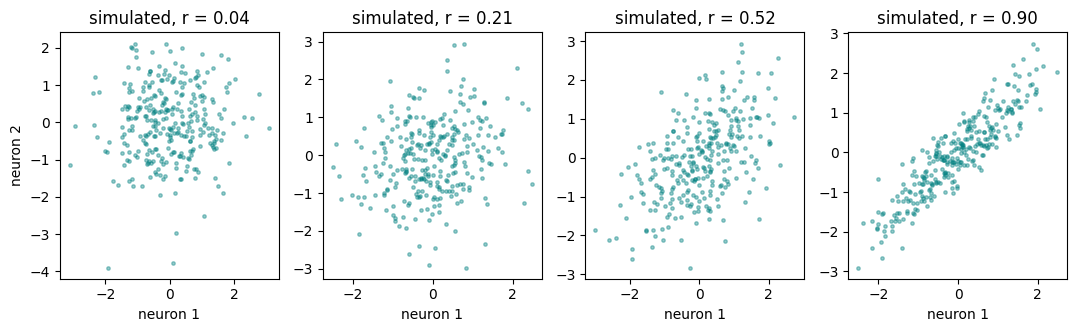

In [68]:
# SIMULATED DATA -- not from the recording. Each panel is a pair of random
# variables generated with a known correlation.
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
for ax, target_r in zip(axes, [0.0, 0.2, 0.5, 0.9]):
    simulated_x = rng.normal(size=300)
    simulated_y = target_r * simulated_x + np.sqrt(1 - target_r ** 2) * rng.normal(size=300)
    ax.scatter(simulated_x, simulated_y, s=6, alpha=0.4, color='teal')
    ax.set_title(f'simulated, r = {np.corrcoef(simulated_x, simulated_y)[0, 1]:.2f}')
    ax.set_xlabel('neuron 1')

axes[0].set_ylabel('neuron 2')
plt.show()

In [69]:
# Mean pairwise correlations in cortex are typically 0.01-0.1 -- weaker than the
# leftmost panel. Real and consequential at the population level, but no single
# pair of neurons looks impressive.


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Correlate two neurons.

Take the full activity traces of two cells, compute the correlation between them with
`np.corrcoef`, and plot one against the other with the r value in the title.

Compare what you see against the simulated panels above.

</div>

In [70]:
# Two cells' full activity traces.
x = activity[:, example_roi]
y = activity[:, example_roi + 1]

r_value = np.corrcoef(x, y)[0, 1]
print('n timepoints:', len(x))
print('r           :', round(r_value, 3))

n timepoints: 42721
r           : 0.143


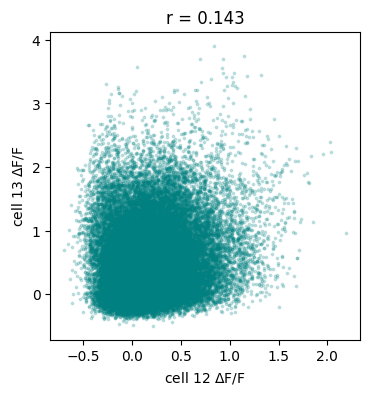

In [71]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(x, y, s=3, alpha=0.2, color='teal')
ax.set_xlabel(f'cell {example_roi} ' + r'$\Delta$F/F')
ax.set_ylabel(f'cell {example_roi + 1} ' + r'$\Delta$F/F')
ax.set_title(f'r = {r_value:.3f}')
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>The two kinds of correlations, and the one array they both come from</h3>

- <b>Signal correlation.</b> Do two cells respond similarly <i>across conditions</i>? Take each
  cell's average response to each condition &mdash; its tuning curve &mdash; and correlate the two
  curves. This is a statement about shared tuning, and so about functional organization.
- <b>Noise correlation.</b> When the <i>same</i> condition repeats, do the two cells fluctuate
  together around their own averages? Remove each condition's mean and correlate what is left. This
  is a statement about shared variability &mdash; <b>not</b> about connectivity, for the reasons
  above.

<b>Both come from the same array.</b> One number per cell, per trial, per condition:

<pre>
responses[condition, trial, cell]
</pre>

Every trial contributes one number for each cell &mdash; its mean activity in a window after onset,
minus its own baseline just before. Once you have that array, the two correlations are two different
ways of collapsing it.

<table>
<tr><td><b>Signal</b></td><td>average over <i>trials</i> &rarr; a tuning curve per cell &rarr;
correlate cells across <i>conditions</i></td></tr>
<tr><td><b>Noise</b></td><td>subtract each condition's mean &rarr; correlate cells across
<i>trials</i>, within one condition &rarr; average those matrices over conditions</td></tr>
</table>

Note which axis each one correlates over, because it sets how many observations you get. With 8
conditions and 400 trials per condition, a signal correlation rests on <b>8</b> paired numbers and a
noise correlation on <b>400</b>. Both render as equally convincing heatmaps.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 1: decide what conditions to compare</h3>

Everything below rests on one choice: which trials count as repeats of the same thing. Get this
wrong and every correlation downstream measures something you did not intend, with no error message.

Not every event in your table is comparable to every other. Two trials can share the same stimulus
label and still differ in what else was happening &mdash; one followed a reward and the other did
not, the animal was running through one and sitting still through the other, one was its first
exposure and one its five hundredth. Those differences do not disappear when you average; they
become part of what you are calling the response.

Pick the subset that makes a fair comparison, pick the column whose value defines the condition, and
write down why. Both choices belong in your methods.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Choose your condition column and your trial subset.

Count how many trials there are of each condition, and check whether they are balanced &mdash; the
least common condition is what limits you. Then say in a sentence which trials you are keeping and
why.

</div>

In [72]:
# How many trials of each condition, and how balanced?
counts = events[condition_column].value_counts()
print(counts.to_string())
print(f'\nleast common: {counts.min()} | most common: {counts.max()} '
      f'| balance {counts.min() / counts.max():.2f}')

image_name
im106      771
im031      699
im075      597
im045      582
im000      548
im054      537
im073      480
im035      430
omitted    161

least common: 161 | most common: 771 | balance 0.21


In [73]:
# CHOICE: condition = image identity, keeping only non-omitted, non-change
# presentations. Repeats outnumber changes ~20:1 and are behaviorally quieter --
# no reward or reliable licking rides along with them.
comparable_trials = events[(events.omitted != 1) & (events.is_change != 1)]

all_onset_times = comparable_trials[onset_column].values
labels = comparable_trials[condition_column].values

print(len(events), 'events ->', len(comparable_trials), 'comparable trials')
print(pd.Series(labels).value_counts().to_string())

4805 events -> 4453 comparable trials
im106    746
im031    676
im075    572
im045    557
im000    523
im054    514
im073    457
im035    408


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 2: build the response array</h3>

One number per cell per trial: mean activity in a <b>response window</b> after onset, minus mean
activity in a <b>baseline window</b> just before it.

The baseline subtraction matters. Without it each trial's "response" includes wherever the cell
happened to be sitting beforehand, and those resting levels drift together across the whole
population as the recording bleaches and the animal's arousal changes. That shared drift becomes a
large positive noise correlation with nothing to do with the stimulus.

The function below does the whole thing. Read it before you run it &mdash; it is eight lines of real
work, and every one of them is a decision you could have made differently. The two window choices
stay <i>outside</i> the function, because they are yours to set and they propagate into every number
in the rest of this notebook.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Choose your windows, then build the array.

1. Set the two windows and check how many samples each one holds. A "baseline" of one sample is not
   an average.
2. Do one cell by hand, and look at the per-trial numbers, so you know what the function is
   producing before you trust it on 60 cells.
3. Run the function and check the shape it hands back.

</div>

In [74]:
# 1. The two windows. These are the decisions -- everything downstream inherits
#    them. The response window should cover the response your Part 3 plot showed.
response_window = (0.0, 0.5)
baseline_window = (-0.5, 0.0)

sampling_interval = np.median(np.diff(timestamps))
print(f'sampling interval: {1000 * sampling_interval:.1f} ms')
print('response samples :', int(0.5 / sampling_interval))
print('baseline samples :', int(0.5 / sampling_interval))

sampling interval: 105.5 ms
response samples : 4
baseline samples : 4


In [75]:
# 2. One cell by hand, so you can see what the function will be doing 60 times.
windows, window_time_axis = align_to_event_times(
    activity[:, example_roi], timestamps, all_onset_times,
    pre=-baseline_window[0], post=response_window[1])

bin_width = np.median(np.diff(window_time_axis))
is_response = window_time_axis >= 0
is_baseline = window_time_axis < -bin_width     # excludes the sample straddling onset

evoked = windows[:, is_response].mean(axis=1) - windows[:, is_baseline].mean(axis=1)

print('windows:', windows.shape, '(n_trials, n_timepoints)')
print('first 5 trials:', np.round(evoked[:5], 4))
print(f'mean {evoked.mean():+.4f}, sd {evoked.std():.4f} across all trials')

windows: (4453, 8) (n_trials, n_timepoints)
first 5 trials: [ 1.0376 -0.4605  0.2124 -0.033   0.2701]
mean +0.0563, sd 0.2092 across all trials


In [76]:
def build_response_array(activity, timestamps, onset_times, labels,
                         response_window, baseline_window):
    """One response value per condition, per trial, per cell.

    Returns
    -------
    responses : (n_conditions, n_trials, n_cells)
        Mean activity in the response window minus mean activity in the baseline
        window, for every cell on every trial, grouped by condition.
    conditions : (n_conditions,)
        The condition label of each slice along the first axis.

    Both correlations in this notebook are computed from this one array -- signal
    by averaging over trials, noise by removing each condition's mean. Which
    means every choice made below shows up in every number you report.
    """
    # ONE CELL AT A TIME. align_to_event_times expects a 1-D trace, and looping
    # keeps it obvious that nothing is mixed across cells. It also silently drops
    # any trial whose window would run off the end of the recording -- which is
    # why we re-derive the label list from the returned length further down.
    per_cell = []
    for cell in range(activity.shape[1]):
        windows, window_time_axis = align_to_event_times(
            activity[:, cell], timestamps, onset_times,
            pre=-baseline_window[0], post=response_window[1])

        # RESPONSE minus BASELINE, per trial. Subtracting each trial's OWN
        # baseline is what removes slow drift in that cell across the session; a
        # single session-wide baseline would leave the drift in the response.
        bin_width = np.median(np.diff(window_time_axis))
        is_response = window_time_axis >= 0
        is_baseline = window_time_axis < -bin_width   # drop the sample straddling onset

        per_cell.append(windows[:, is_response].mean(axis=1)
                        - windows[:, is_baseline].mean(axis=1))

    # The loop built one row per CELL; everything downstream wants trials first.
    trial_by_cell = np.array(per_cell).T
    trial_labels = np.asarray(labels)[:len(trial_by_cell)]

    # GROUP BY CONDITION. Stacking into a rectangular array needs the same trial
    # count in every condition, so each one is truncated to the length of the
    # least common. Those dropped trials are real data you are choosing not to
    # use -- if your conditions are badly unbalanced, most of your data is here.
    conditions = np.unique(trial_labels)
    n_trials = min((trial_labels == c).sum() for c in conditions)

    responses = np.stack([trial_by_cell[trial_labels == c][:n_trials]
                          for c in conditions])
    return responses, conditions

In [77]:
# 3. Run it. The shape is the thing to check: conditions, trials, cells.
responses, conditions = build_response_array(
    activity, timestamps, all_onset_times, labels,
    response_window, baseline_window)

# Every cell pair exactly once, leaving out the diagonal (which is 1 by
# construction). Used by every correlation summary below.
pairs = np.triu_indices(responses.shape[2], k=1)

print('responses:', responses.shape, '(n_conditions, n_trials, n_cells)')
print('conditions:', list(conditions), '| unique cell pairs:', len(pairs[0]))

responses: (8, 408, 80) (n_conditions, n_trials, n_cells)
conditions: ['im000', 'im031', 'im035', 'im045', 'im054', 'im073', 'im075', 'im106'] | unique cell pairs: 3160


In [78]:
# What did the truncation cost? Compare the trials kept against the trials
# available for each condition.
available = pd.Series(labels).value_counts().sort_index()
print(f'kept {responses.shape[1]} trials per condition, out of:')
print(available.to_string())
print(f'\ntotal used: {responses.shape[0] * responses.shape[1]} of {len(labels)} trials')

kept 408 trials per condition, out of:
im000    523
im031    676
im035    408
im045    557
im054    514
im073    457
im075    572
im106    746

total used: 3264 of 4453 trials


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 3: signal correlations</h3>

Two steps, in this order:

1. **Average over trials** &mdash; `responses.mean(axis=1)` gives `(condition, cell)`. Each column is
   one cell's tuning curve.
2. **Correlate the cells** across conditions.

Plot the tuning curves before you correlate them. A correlation matrix computed from flat,
featureless curves looks exactly as convincing as one computed from sharply tuned cells.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Compute the tuning curves, plot them, then correlate them.

`np.corrcoef` correlates **rows**, and cells are the columns of your tuning array &mdash; so
transpose. Check the output shape against your number of cells.

</div>

In [79]:
# Average over trials -> one tuning curve per cell.
tuning_curves = responses.mean(axis=1)

print('tuning_curves:', tuning_curves.shape, '(n_conditions, n_cells)')

tuning_curves: (8, 80) (n_conditions, n_cells)


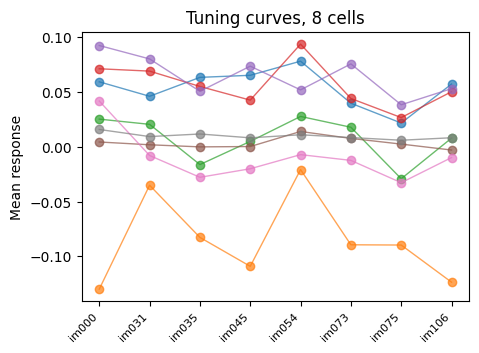

In [80]:
fig, ax = plt.subplots(figsize=(5, 3.5))
for roi in range(8):
    ax.plot(tuning_curves[:, roi], marker='o', lw=1, alpha=0.7)
ax.set_xticks(range(len(conditions)))
ax.set_xticklabels(conditions, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Mean response')
ax.set_title('Tuning curves, 8 cells')
plt.show()

In [81]:
# Correlate the cells. .T because np.corrcoef correlates ROWS and cells are columns.
signal_correlations = np.corrcoef(tuning_curves.T)

print('signal_correlations:', signal_correlations.shape, '| n_cells:', responses.shape[2])
print('observations behind each value:', responses.shape[0], 'conditions')

signal_correlations: (80, 80) | n_cells: 80
observations behind each value: 8 conditions


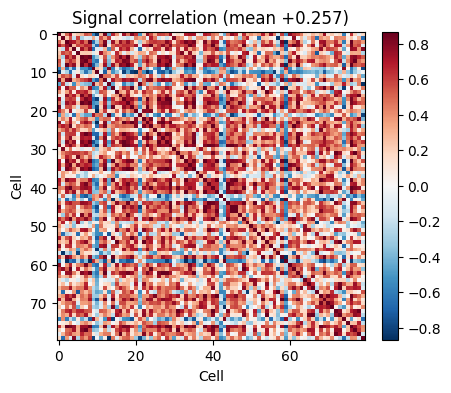

In [82]:
# Colour limit at the 98th percentile of the off-diagonal values -- the diagonal
# is 1 by construction and would set the scale for everything else.
vmax = np.percentile(np.abs(signal_correlations[pairs]), 98)

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(signal_correlations, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_xlabel('Cell')
ax.set_ylabel('Cell')
ax.set_title(f'Signal correlation (mean {signal_correlations[pairs].mean():+.3f})')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 4: noise correlations</h3>

Same array, collapsed the other way:

1. **Remove each condition's mean** from its own trials. What is left is everything the condition
   does not explain.
2. **Correlate the cells across trials, within one condition** &mdash; this gives one cell &times;
   cell matrix per condition.
3. **Average those matrices** over conditions.

Two things to be careful about. Subtract each condition's <b>own</b> mean, not the grand mean:
subtracting the grand mean leaves the differences between conditions in the residuals, which makes
your "noise" correlation partly a signal correlation. And note that the correlation runs over
<b>trials</b> &mdash; a single trial gives one number per cell, which is not enough to correlate
anything.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Compute the residuals, then the noise correlations.

A **residual** is what is left of a trial once you subtract the average of the trials it belongs
with. If one image evokes a mean response of 0.05 and this trial gave 0.07, the residual is +0.02
&mdash; this trial ran hotter than the condition explains. Residuals average to zero within each
condition by construction, so all the condition structure is gone and what remains is the
trial-to-trial wobble.

Check that the residuals do average to about zero within every condition. If they do not, you
subtracted the wrong mean.

</div>

In [83]:
# Remove each condition's own mean. keepdims keeps the shape broadcastable.
residuals = responses - responses.mean(axis=1, keepdims=True)

print('residuals:', residuals.shape)
print('mean within each condition:', np.round(residuals.mean(axis=(1, 2)), 12))

residuals: (8, 408, 80)
mean within each condition: [-2.630e-09  8.180e-10  0.000e+00  1.750e-10 -4.090e-10 -1.170e-10
 -4.670e-10  1.286e-09]


In [84]:
# One correlation matrix per condition, correlating cells across that
# condition's trials. Then average the matrices.
per_condition = [np.corrcoef(residuals[i].T) for i in range(len(conditions))]
noise_correlations = np.mean(per_condition, axis=0)

print('noise_correlations:', noise_correlations.shape)
print('observations behind each value:', responses.shape[1], 'trials per condition')

noise_correlations: (80, 80)
observations behind each value: 408 trials per condition


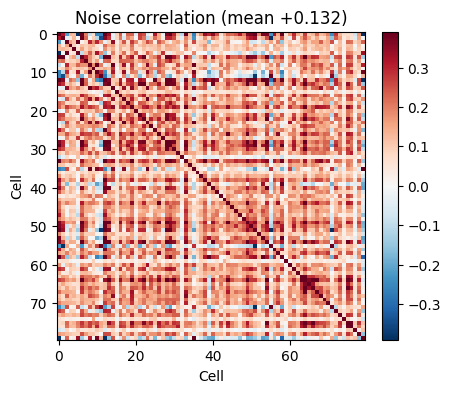

In [85]:
vmax = np.percentile(np.abs(noise_correlations[pairs]), 98)

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(noise_correlations, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_xlabel('Cell')
ax.set_ylabel('Cell')
ax.set_title(f'Noise correlation (mean {noise_correlations[pairs].mean():+.3f})')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 5: put them side by side</h3>

Do cells that like the same stimuli also fluctuate together? Plot one against the other, a point per
cell pair.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Plot the signal and noise correlation heatmaps next to each other, then plot the relationship between them as a scatterplot. 
The x-axis should show the signal correlation for each pair of neurons and the y-axis should show the noise correlation for each pair. 

How strong is the relationship? What does it mean? 
</div>

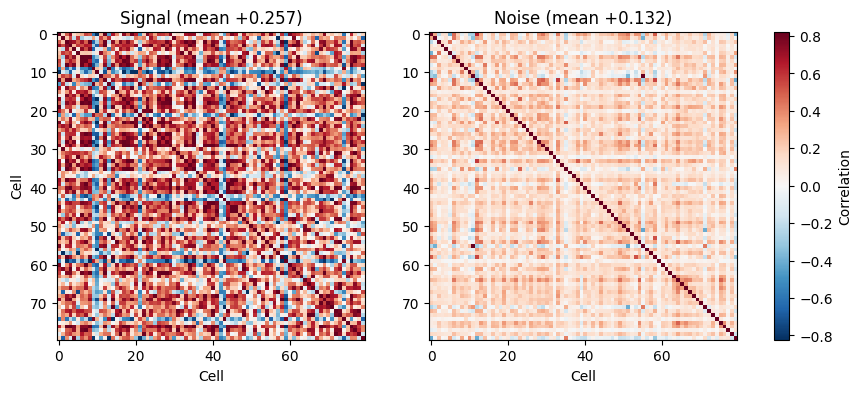

In [86]:
# Both matrices on the SAME colour scale, so the comparison is fair.
vmax = np.percentile(np.abs(np.concatenate([signal_correlations[pairs],
                                            noise_correlations[pairs]])), 98)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))

for ax, matrix, name in zip(axes, [signal_correlations, noise_correlations],
                            ['Signal', 'Noise']):
    im = ax.imshow(matrix, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_xlabel('Cell')
    ax.set_title(f'{name} (mean {matrix[pairs].mean():+.3f})')

axes[0].set_ylabel('Cell')
plt.colorbar(im, ax=axes, fraction=0.023, label='Correlation')
plt.show()

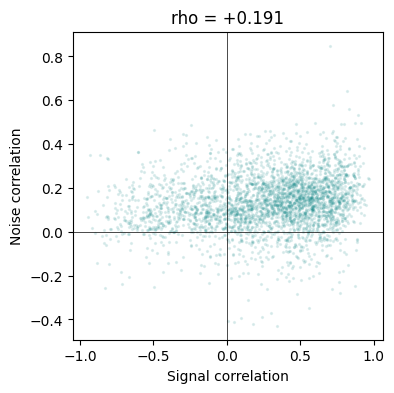

In [87]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(signal_correlations[pairs], noise_correlations[pairs],
           s=2, alpha=0.1, color='teal')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('Signal correlation')
ax.set_ylabel('Noise correlation')
rho = stats.spearmanr(signal_correlations[pairs], noise_correlations[pairs]).statistic
ax.set_title(f'rho = {rho:+.3f}')
plt.show()

In [88]:
# Compare the two matrices' TEXTURE, not their numbers. One usually has visible
# structure and the other is closer to salt-and-pepper -- and both came from the
# same array.
#
# A positive relationship in the scatter is the classic result, found in
# essentially every cortical area: cells that like the same stimuli also share
# their trial-to-trial fluctuations. It matters for coding, because shared
# variability aligned with the signal does not average away as you add neurons --
# and it says nothing about whether those cells are connected (see the caveat above).


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Is this result trustworthy?</h1>

Every number so far is a point estimate with no error bar. The single most useful check: **would you
get the same answer with half the data?**

Split the trials in half at random, compute the correlations on each half separately, and correlate
the two halves' answers. Split **within each condition** so both halves see every condition.

Three outcomes, and all three are informative:

- **One high, one low** &mdash; trust the high one, and say why the other is not trustworthy.
- **Both high** &mdash; you have enough data for both; proceed.
- **Both near zero** &mdash; report that. It usually means the condition variable you chose does not
  organize these neurons' responses, however well-balanced it looked. That is a real result about
  your dataset, and it is a better README than a matrix you cannot defend.

The cell below is worked for you. Run it on your own `responses` array.

</div>

In [89]:
# First make sure your response array is saved to a variable called "responses" so the following code will run

In [90]:
# Split the trials of each condition into two halves, and compute both
# correlations on each half separately.
rng = np.random.default_rng(0)
n_half = responses.shape[1] // 2

shuffled = rng.permutation(responses.shape[1])
half_a = responses[:, shuffled[:n_half]]
half_b = responses[:, shuffled[n_half:2 * n_half]]

print('half_a:', half_a.shape, '| half_b:', half_b.shape)

half_a: (8, 204, 80) | half_b: (8, 204, 80)


In [91]:
# Signal correlations from each half, then how well the two agree over cell pairs.
signal_a = np.corrcoef(half_a.mean(axis=1).T)
signal_b = np.corrcoef(half_b.mean(axis=1).T)

signal_reliability = stats.spearmanr(signal_a[pairs], signal_b[pairs]).statistic
print(f'signal correlation reliability: {signal_reliability:.3f}')
print(f'  from {responses.shape[0]} conditions per half')

signal correlation reliability: 0.348
  from 8 conditions per half


In [92]:
# Same for noise correlations.
noise_a = np.mean([np.corrcoef((half_a[i] - half_a[i].mean(axis=0)).T)
                   for i in range(len(conditions))], axis=0)
noise_b = np.mean([np.corrcoef((half_b[i] - half_b[i].mean(axis=0)).T)
                   for i in range(len(conditions))], axis=0)

noise_reliability = stats.spearmanr(noise_a[pairs], noise_b[pairs]).statistic
print(f'noise correlation reliability: {noise_reliability:.3f}')
print(f'  from {n_half} trials per condition per half')

noise correlation reliability: 0.950
  from 204 trials per condition per half


In [93]:
# Noise correlations reproduce across independent halves; signal correlations
# barely do. The reason is the observation counts printed above: each noise
# correlation comes from hundreds of trials, each signal correlation from one
# number per condition. Correlating two short vectors is noisy no matter how many
# trials went into each entry -- and nothing in the heatmaps told you that.


---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Summary</h1>

<h3>The process</h3>

1. **Find out what is in the file** before analyzing it &mdash; and check that the dataset supports
   your question. Sometimes the answer is no.
2. **Plot the data after each transformation.** Single trials before averages; tuning curves before
   correlations.
3. **Name every decision.** Event subset, condition column, response window, baseline. Each is a
   fork, and each belongs in your methods.
4. **Try to break your own result.** Split the data in half and see if the answer survives.
5. **Let the dataset answer back.** If the check says your result is noise, or the dataset has no
   variable that supports your question, that is the finding. Report it rather than reaching for the
   analysis you planned to run.

<h3>Traps this notebook demonstrated</h3>

| trap | how you catch it |
| --- | --- |
| A result from few observations looks like one from many | split-half reliability |
| Analyzing units that should have been dropped | select on quality columns, and say so |
| Epoch comparisons confounded with time and behavior | check durations, order, behavior |
| An example cell chosen to look good | state your selection rule |
| Data looks absent but is stored elsewhere | look in every container first |
| An index from an earlier cell after reshaping the data | re-derive indices, never carry them |

<h3>Why this matters</h3>

You can generate an analysis faster than you can validate one. The only defense is to know your data
well enough that a wrong answer looks wrong to **you** &mdash; because it will not look wrong to the
code, and it will not look wrong on the plot.

</div>